# Hybrid TE Classifier — v4.4

## What changed from v4.3

**Problem (inherited from v3):** Boundary/position prediction was poor.
- Absolute start/end Pearson r ≈ 0.07–0.18 (near-random)
- Length prediction was fine (r ≈ 0.94) — but the model couldn't localise *where* in the canvas the sequence sits
- Root cause 1: the boundary regression head reads from `masked_avg_pool` output, which is **position-invariant by design** — no spatial information survives
- Root cause 2: the regression target (`start_pos`) is drawn from `randint` at each epoch — it is literally a random variable, uncorrelated with sequence content

**v4.4 fixes two things at the model architecture level:**

### Fix 1 — Sinusoidal positional encoding on the CNN input
`pos_freq = 4` sinusoidal channels (log-spaced frequencies 1, 2, 4, 8 cycles/canvas) are appended to the 5-channel one-hot input before the motif convolutions, giving the model canvas-position awareness. This partially breaks translation equivariance so the model can correlate learned features with absolute canvas position.

### Fix 2 — Per-position segmentation head
Instead of a regression head on the pooled vector, a `Conv1d(width, 1, 1)` segmentation head is attached to the **spatial feature map `z`** just before the final average pool. It outputs per-position binary logits (sequence vs padding) at 1/16 the canvas resolution (after 4 × stride-2 max-pools). The training target is the downsampled boolean mask (already computed in `collate_hybrid`).

The segmentation loss is `BCEWithLogitsLoss` on the downsampled mask, added to the total loss with weight `SEG_WEIGHT = 0.1`. The obsolete 3-output MSE regression head (`boundary_head`) is removed.

### Other v4.4 changes
- `CNNTower.encode()` now returns `(pooled, z_spatial, mask_down)` instead of just `pooled`
- `HybridTEClassifierV4.forward()` returns `(class_logits, sf_logits, gate_weights, seg_logits)`
- Training history tracks `val_seg_iou` each epoch
- Checkpoint prefix updated to `hybrid_v4.4`

In [1]:
# ============ Imports ============
import gc
import math
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.optim.lr_scheduler import CosineAnnealingLR
from pathlib import Path
from dataclasses import dataclass
from typing import List, Dict, Tuple, Optional
from collections import Counter
from tqdm.auto import tqdm

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, f1_score,
    classification_report, confusion_matrix,
    roc_auc_score, average_precision_score
)

import matplotlib.pyplot as plt
import seaborn as sns

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if hasattr(torch.backends, 'mps'):
    print(f"MPS available: {torch.backends.mps.is_available()}")

PyTorch version: 2.9.0
CUDA available: False
MPS available: True


In [2]:
# ============ Configuration ============
FASTA_PATH = "../../../data/vgp/all_vgp_tes.fa"
LABEL_PATH = "../../../data/vgp/20260120_features_sf"

# Benchmark genomes to exclude from training (avoid data leakage)
# These genomes are used for independent validation in mini_benchmark/
EXCLUDE_GENOMES = {'mOrnAna', 'bTaeGut', 'rAllMis'}

# Model hyperparameters
FIXED_LENGTH = 20000          # CNN canvas size
MIN_CLASS_COUNT = 100         # Minimum samples per superfamily
MAX_PER_SF = 3000             # Max samples per superfamily (subsample large classes)
LABEL_SMOOTHING = 0.1

# Top-level class configuration (replaces binary DNA+/None)
KEEP_CLASSES = ['DNA', 'LTR', 'LINE']  # Drop None, SINE, PLE, RC
CLASS_NAMES = KEEP_CLASSES             # 3-class head: DNA vs LTR vs LINE
N_CLASSES = len(CLASS_NAMES)

# K-mer GNN parameters
KMER_K = 7                   # K-mer size
KMER_DIM = 2048              # Hash dimension
KMER_WINDOW = 512            # Window size for k-mer features
KMER_STRIDE = 256            # Stride for sliding window
GNN_HIDDEN = 128             # GNN hidden dimension
GNN_LAYERS = 3               # Number of GNN layers

# CNN parameters
CNN_WIDTH = 128              # CNN channel width
MOTIF_KERNELS = (7, 15, 21)  # Multi-scale motif detection
CONTEXT_DILATIONS = (1, 2, 4, 8)  # Dilated convolutions
RC_FUSION_MODE = "late"      # "early" or "late" RC fusion
POS_FREQ = 4                 # v4.4: sinusoidal PE frequencies appended to one-hot input

# Fusion parameters
FUSION_DIM = 256             # Attention fusion dimension
NUM_HEADS = 4                # Number of attention heads

# Training parameters
BATCH_SIZE = 16              # Smaller batch for dual-tower model
EPOCHS = 40
LR = 1e-3
DROPOUT = 0.15

# v4.4: segmentation loss weight (boundary localisation auxiliary task)
SEG_WEIGHT = 0.1             # Weight for BCEWithLogitsLoss on per-position segmentation head


# Cross-validation / data split constants (used in training & overfitting analysis)
TEST_SIZE = 0.2              # Held-out test set fraction
N_FOLDS = 5                  # Number of K-fold CV folds
def resolve_device(requested=None):
    """Return the best available accelerator."""
    if requested is not None:
        return torch.device(requested)
    if torch.cuda.is_available():
        return torch.device("cuda")
    if hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
        return torch.device("mps")
    return torch.device("cpu")

DEVICE = resolve_device()
print(f"Using device: {DEVICE}")


Using device: mps


## Data Loading Utilities

In [3]:
# ============ FASTA and Label Loading ============

def read_fasta(path):
    """Read FASTA file and return headers and sequences."""
    headers, sequences = [], []
    h, buf = None, []
    
    with open(path, 'r') as f:
        for line in f:
            if not line:
                continue
            if line[0] == '>':
                if h is not None:
                    sequences.append(''.join(buf).upper())
                    buf = []
                h = line[1:].strip()
                headers.append(h)
            else:
                buf.append(line.strip())
        if h is not None:
            sequences.append(''.join(buf).upper())
    return headers, sequences


def load_multiclass_labels(label_path, keep_classes=('DNA', 'LTR', 'LINE')):
    """
    Load labels for multi-class hierarchical classification.
    
    Args:
        label_path: Path to label file (header<TAB>superfamily).
        keep_classes: Top-level classes to keep (e.g., DNA, LTR, LINE).
                      All others (None, SINE, PLE, RC) are dropped.
    
    Returns:
        label_dict: header -> tag (superfamily string)
        class_dict: header -> class_id (0=DNA, 1=LTR, 2=LINE based on order in keep_classes)
    """
    label_path = Path(label_path)
    class_to_id = {c: i for i, c in enumerate(keep_classes)}
    
    label_dict, class_dict = {}, {}
    superfamilies = Counter()
    skipped_classes = Counter()
    
    with label_path.open("r") as f:
        for line in f:
            line = line.strip()
            if not line or line.startswith("#"):
                continue
            parts = line.split()
            if len(parts) < 2:
                continue
            header = parts[0].lstrip('>')
            tag = parts[1]
            
            # Get top-level class from tag (e.g., "DNA/hAT" -> "DNA")
            top_class = tag.split('/')[0]
            
            # Only keep sequences from keep_classes
            if top_class in class_to_id:
                label_dict[header] = tag
                class_dict[header] = class_to_id[top_class]
                superfamilies[tag] += 1
            else:
                skipped_classes[tag] += 1
    
    print(f"Loaded {len(label_dict)} sequences (filtered to {keep_classes})")
    print(f"\\nSuperfamily distribution by class:")
    for cls in keep_classes:
        cls_tags = {t for t in superfamilies if t == cls or t.startswith(cls + "/")}
        cls_count = sum(superfamilies[t] for t in cls_tags)
        print(f"\\n  {cls} ({cls_count} total):")
        for tag, count in sorted(superfamilies.items(), key=lambda x: -x[1]):
            if tag in cls_tags:
                pct = 100 * count / len(label_dict)
                print(f"    ✓ {tag}: {count} ({pct:.1f}%)")
    
    if skipped_classes:
        print(f"\\nDropped classes:")
        for tag, count in sorted(skipped_classes.items(), key=lambda x: -x[1])[:10]:
            print(f"    ✗ {tag}: {count}")
        if len(skipped_classes) > 10:
            print(f"    ... and {len(skipped_classes) - 10} more")
    
    # Summary
    print(f"\\nClass distribution:")
    for cls, cls_id in class_to_id.items():
        n = sum(1 for v in class_dict.values() if v == cls_id)
        print(f"  {cls} (id={cls_id}): {n}")
    
    return label_dict, class_dict


def compute_class_weights(y_ids, n_classes, mode="inv_sqrt", eps=1e-6):
    """Compute class weights for imbalanced multi-class."""
    counts = np.bincount(np.asarray(y_ids, dtype=np.int64), minlength=n_classes).astype(np.float64)
    if mode == "none":
        w = np.ones(n_classes, dtype=np.float32)
    elif mode == "inv":
        w = 1.0 / (counts + eps)
    elif mode == "inv_sqrt":
        w = 1.0 / np.sqrt(counts + eps)
    else:
        raise ValueError(f"Unknown mode={mode}")
    w = w / (w.mean() + 1e-12)
    return w.astype(np.float32)

## K-mer Featurizer (from GNN model)

In [4]:
# ============ K-mer Feature Extraction ============

# ASCII -> {0,1,2,3,4} for A,C,G,T,other
_ASCII_MAP = np.full(256, 4, dtype=np.uint8)
for ch, val in [("A", 0), ("C", 1), ("G", 2), ("T", 3), ("a", 0), ("c", 1), ("g", 2), ("t", 3)]:
    _ASCII_MAP[ord(ch)] = val

_COMP = np.array([3, 2, 1, 0], dtype=np.uint8)  # A<->T, C<->G


def kmer_code_forward(arr4: np.ndarray) -> int:
    code = 0
    for v in arr4:
        code = (code << 2) | int(v)
    return code


def kmer_code_rc(arr4: np.ndarray) -> int:
    code = 0
    for v in arr4[::-1]:
        code = (code << 2) | int(_COMP[v])
    return code


def canonical_kmer_code(arr4: np.ndarray) -> int:
    c1 = kmer_code_forward(arr4)
    c2 = kmer_code_rc(arr4)
    return c1 if c1 < c2 else c2


def hash_u32(x: int, dim: int) -> int:
    z = (x * 0x9E3779B97F4A7C15) & 0xFFFFFFFFFFFFFFFF
    z ^= (z >> 33)
    z = (z * 0xC2B2AE3D27D4EB4F) & 0xFFFFFFFFFFFFFFFF
    z ^= (z >> 29)
    return int(z % dim)


@dataclass
class KmerWindowFeaturizer:
    """Extract k-mer frequency features from sliding windows."""
    k: int = 7
    dim: int = 2048
    window: int = 512
    stride: int = 256
    add_pos: bool = True
    l2_normalize: bool = True

    def featurize_sequence(self, seq: str) -> Tuple[np.ndarray, np.ndarray]:
        arr = _ASCII_MAP[np.frombuffer(seq.encode("ascii", "ignore"), dtype=np.uint8)]
        L = int(arr.size)
        
        if L == 0:
            X = np.zeros((1, self.dim + (1 if self.add_pos else 0)), dtype=np.float32)
            return X, np.array([0], dtype=np.int64)

        if L <= self.window:
            starts = np.array([0], dtype=np.int64)
        else:
            starts = np.arange(0, L - self.window + 1, self.stride, dtype=np.int64)
            if starts.size == 0:
                starts = np.array([0], dtype=np.int64)

        out_dim = self.dim + (1 if self.add_pos else 0)
        X = np.zeros((starts.size, out_dim), dtype=np.float32)

        for wi, st in enumerate(starts):
            en = min(st + self.window, L)
            sub = arr[st:en]
            counts = np.zeros(self.dim, dtype=np.float32)
            total = 0

            k = self.k
            if sub.size >= k:
                for i in range(0, sub.size - k + 1):
                    kmer = sub[i:i + k]
                    if np.any(kmer == 4):
                        continue
                    code = canonical_kmer_code(kmer)
                    j = hash_u32(code, self.dim)
                    counts[j] += 1.0
                    total += 1

            if total > 0:
                counts /= float(total)

            if self.l2_normalize:
                nrm = np.linalg.norm(counts)
                if nrm > 0:
                    counts /= nrm

            if self.add_pos:
                center = (st + en) / 2.0
                pos = center / max(1.0, float(L))
                X[wi, :-1] = counts
                X[wi, -1] = pos
            else:
                X[wi, :] = counts

        return X, starts


def build_chain_edge_index(n: int, undirected: bool = True, self_loops: bool = True) -> torch.Tensor:
    """Build edge index for a chain graph (windows connected sequentially)."""
    edges = []
    if n > 1:
        src = np.arange(n - 1, dtype=np.int64)
        dst = np.arange(1, n, dtype=np.int64)
        edges.append((src, dst))
        if undirected:
            edges.append((dst, src))
    if self_loops:
        idx = np.arange(n, dtype=np.int64)
        edges.append((idx, idx))
    if not edges:
        ei = np.zeros((2, 0), dtype=np.int64)
    else:
        s = np.concatenate([e[0] for e in edges])
        d = np.concatenate([e[1] for e in edges])
        ei = np.stack([s, d], axis=0)
    return torch.from_numpy(ei)

## Hybrid Dataset (CNN + GNN features)

In [5]:
# ============ Encoding for CNN ============

# Mapping ACGT to 0-3, N to 4
ENCODE = np.full(256, 4, dtype=np.int64)
for ch, idx in zip(b"ACGTNacgtn", [0, 1, 2, 3, 4, 0, 1, 2, 3, 4]):
    ENCODE[ch] = idx

# Reverse complement: ACGTN -> TGCAN -> indices [3, 2, 1, 0, 4]
REV_COMP = torch.tensor([3, 2, 1, 0, 4], dtype=torch.long)


class HybridDataset(Dataset):
    """
    Dataset that provides both CNN (one-hot) and GNN (k-mer) features.
    
    For each sequence:
    - CNN: One-hot encoding placed randomly in fixed-length canvas
    - GNN: Pre-computed k-mer window features
    """
    def __init__(
        self,
        headers: List[str],
        sequences: List[str],
        binary_labels: np.ndarray,
        class_labels: np.ndarray,
        kmer_features: List[np.ndarray],  # Pre-computed k-mer features
        fixed_length: int = FIXED_LENGTH
    ):
        self.headers = list(headers)
        self.sequences = list(sequences)
        self.binary_labels = np.asarray(binary_labels, dtype=np.int64)
        self.class_labels = np.asarray(class_labels, dtype=np.int64)
        self.kmer_features = kmer_features
        self.fixed_length = fixed_length
        self.seq_lengths = np.array([len(s) for s in sequences], dtype=np.int64)

    def __len__(self):
        return len(self.sequences)

    def __getitem__(self, idx):
        seq = self.sequences[idx]
        seq_len = len(seq)

        # Encode sequence for CNN
        seq_bytes = seq.encode("ascii", "ignore")
        seq_idx = ENCODE[np.frombuffer(seq_bytes, dtype=np.uint8)]

        # Random placement in canvas
        max_start = max(0, self.fixed_length - seq_len)
        start_pos = np.random.randint(0, max_start + 1) if max_start > 0 else 0
        end_pos = start_pos + seq_len

        # K-mer features (pre-computed)
        kmer_feat = self.kmer_features[idx]  # (n_windows, kmer_dim+1)

        return (
            self.headers[idx],
            seq_idx,
            int(self.binary_labels[idx]),
            int(self.class_labels[idx]),
            start_pos,
            end_pos,
            seq_len,
            kmer_feat
        )


def collate_hybrid(batch, fixed_length=FIXED_LENGTH):
    """
    Collate function for hybrid model.
    
    Returns:
        headers: list of header strings
        X_cnn: (B, 5, fixed_length) one-hot for CNN
        mask: (B, fixed_length) padding mask
        Y_binary: (B,) binary labels
        Y_class: (B,) class labels
        x_gnn: (total_nodes, feat_dim) stacked node features
        edge_index: (2, total_edges) graph edges
        batch_vec: (total_nodes,) batch assignment
    """
    (headers, seq_idxs, binary_labels, class_labels, 
     starts, ends, lengths, kmer_feats) = zip(*batch)

    B = len(batch)
    
    # ---- CNN inputs ----
    X_cnn = torch.zeros((B, 5, fixed_length), dtype=torch.float32)
    mask = torch.zeros((B, fixed_length), dtype=torch.bool)

    for i, (seq_idx, start, end, seq_len) in enumerate(zip(seq_idxs, starts, ends, lengths)):
        actual_len = min(seq_len, fixed_length - start)
        if actual_len > 0:
            idx = torch.from_numpy(seq_idx[:actual_len].astype(np.int64))
            pos = torch.arange(actual_len, dtype=torch.long) + start
            X_cnn[i, idx, pos] = 1.0
            mask[i, start:start + actual_len] = (idx != 4)

    Y_binary = torch.tensor(binary_labels, dtype=torch.long)
    Y_class = torch.tensor(class_labels, dtype=torch.long)

    # ---- GNN inputs ----
    xs, eis, batch_vecs = [], [], []
    node_offset = 0

    for gi, kmer_feat in enumerate(kmer_feats):
        x = torch.from_numpy(kmer_feat).to(torch.float32)
        n = x.size(0)
        ei = build_chain_edge_index(n, undirected=True, self_loops=True)
        
        xs.append(x)
        eis.append(ei + node_offset)
        batch_vecs.append(torch.full((n,), gi, dtype=torch.int64))
        node_offset += n

    x_gnn = torch.cat(xs, dim=0)
    edge_index = torch.cat(eis, dim=1) if eis else torch.zeros((2, 0), dtype=torch.int64)
    batch_vec = torch.cat(batch_vecs, dim=0)

    return (
        list(headers), X_cnn, mask, Y_binary, Y_class,
        x_gnn, edge_index, batch_vec
    )

## CNN Tower (from v3 model)

In [6]:
# ============ CNN Building Blocks ============

class ConvBlock(nn.Module):
    """Residual convolutional block with optional dilation."""
    def __init__(self, c_in, c_out, kernel_size=9, dilation=1, dropout=0.1):
        super().__init__()
        assert kernel_size % 2 == 1
        pad = (kernel_size // 2) * dilation
        self.conv = nn.Conv1d(c_in, c_out, kernel_size, padding=pad, dilation=dilation, bias=True)
        self.bn = nn.BatchNorm1d(c_out)
        self.drop = nn.Dropout(dropout)
        self.proj = nn.Identity() if c_in == c_out else nn.Conv1d(c_in, c_out, 1)

    def forward(self, x):
        y = self.conv(x)
        y = F.gelu(self.bn(y))
        y = self.drop(y)
        return y + self.proj(x)


class MaskedMaxPool1d(nn.Module):
    """Max pooling that respects padding mask."""
    def __init__(self, kernel_size=2, stride=2):
        super().__init__()
        self.kernel_size = kernel_size
        self.stride = stride

    def forward(self, x, mask):
        if mask is not None:
            m = mask.unsqueeze(1).float()
            x = x * m + (~mask.unsqueeze(1)) * (-1e9)
        x_p = F.max_pool1d(x, self.kernel_size, self.stride)
        if mask is None:
            return x_p, None
        m_p = F.max_pool1d(mask.float().unsqueeze(1), self.kernel_size, self.stride).squeeze(1) > 0
        return x_p, m_p


def masked_avg_pool(z, mask):
    """Global average pooling respecting mask."""
    if mask is None:
        return z.mean(-1)
    m = mask.unsqueeze(1).float()
    return (z * m).sum(-1) / m.sum(-1).clamp_min(1.0)


class RCFirstConv1d(nn.Module):
    """RC-invariant first convolution (early fusion)."""
    def __init__(self, out_channels, kernel_size=15, dilation=1, bias=True, dropout=0.1):
        super().__init__()
        assert kernel_size % 2 == 1
        pad = (kernel_size // 2) * dilation
        self.conv = nn.Conv1d(5, out_channels, kernel_size, padding=pad, dilation=dilation, bias=bias)
        self.batch_norm = nn.BatchNorm1d(out_channels)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        y1 = self.conv(x)
        x_rc = x.flip(-1).index_select(1, REV_COMP.to(x.device))
        y2 = self.conv(x_rc).flip(-1)
        y = torch.max(y1, y2)
        y = self.batch_norm(y)
        y = F.gelu(y)
        y = self.dropout(y)
        return y

In [7]:
# ============ CNN Tower (v4.4) ============

class CNNTower(nn.Module):
    """
    CNN tower for sequence motif detection.

    v4.4 additions:
    - Sinusoidal positional encoding (pos_freq channels) is appended to the
      5-channel one-hot input before the motif convolutions, giving the model
      canvas-position awareness so it can localise where in the canvas the
      sequence sits.
    - encode() now returns (pooled, z_spatial, mask_down) so the caller can
      attach a per-position segmentation head to z_spatial.
    - A 1×1 Conv segmentation head (seg_head) is included in this module;
      forward() returns (pooled, seg_logits) where seg_logits is derived from
      the FORWARD branch only (RC branch is only used for the pooled embedding).
    """
    def __init__(
        self,
        width: int = 128,
        motif_kernels: Tuple[int, ...] = (7, 15, 21),
        context_kernel: int = 9,
        context_dilations: Tuple[int, ...] = (1, 2, 4, 8),
        dropout: float = 0.15,
        rc_mode: str = "late",
        pos_freq: int = 4,    # v4.4: number of sinusoidal PE channels
    ):
        super().__init__()
        self.rc_mode = rc_mode
        self.out_dim = width
        self.pos_freq = pos_freq

        # Input channels after appending positional encoding
        in_ch_seq = 5 + pos_freq   # one-hot (5) + sinusoidal PE (pos_freq)

        # Motif detection layers
        if rc_mode == "early":
            # Note: RCFirstConv1d still uses 5-channel input in "early" mode.
            # Positional encoding is skipped for early-mode (use "late" for v4.4).
            self.motif_convs = nn.ModuleList([
                RCFirstConv1d(width, kernel_size=k, dropout=dropout)
                for k in motif_kernels
            ])
        else:
            self.motif_convs = nn.ModuleList([
                nn.Sequential(
                    nn.Conv1d(in_ch_seq, width, kernel_size=k, padding=k // 2, bias=True),
                    nn.BatchNorm1d(width),
                    nn.GELU(),
                    nn.Dropout(dropout)
                )
                for k in motif_kernels
            ])

        # Mix layer
        in_ch = width * len(motif_kernels)
        self.mix = nn.Sequential(
            nn.Conv1d(in_ch, width, kernel_size=1, bias=True),
            nn.BatchNorm1d(width),
            nn.GELU(),
            nn.Dropout(dropout),
        )

        # Context blocks with dilation
        self.context_blocks = nn.ModuleList([
            ConvBlock(width, width, kernel_size=context_kernel, dilation=d, dropout=dropout)
            for d in context_dilations
        ])
        self.pool = MaskedMaxPool1d(kernel_size=2, stride=2)

        # v4.4: per-position segmentation head (1×1 conv on the spatial feature map)
        # Outputs one logit per spatial position (sequence vs padding).
        self.seg_head = nn.Conv1d(width, 1, kernel_size=1)

    def _add_pos_enc(self, x: torch.Tensor) -> torch.Tensor:
        """Append sinusoidal positional encoding channels to one-hot input.

        Uses log-spaced frequencies (1, 2, 4, 8 cycles per canvas) so the
        model can distinguish both coarse and fine canvas positions.

        Args:
            x: (B, 5, L) one-hot encoded sequence on the canvas
        Returns:
            (B, 5 + pos_freq, L)
        """
        B, C, L = x.shape
        # Normalised position 0→1 across the canvas
        pos = torch.arange(L, device=x.device, dtype=x.dtype) / max(L - 1, 1)
        # Log-spaced frequencies: 1, 2, 4, ... cycles per canvas
        freqs = 2.0 ** torch.arange(self.pos_freq, device=x.device, dtype=x.dtype)
        # pe: (pos_freq, L)
        pe = torch.sin(math.pi * pos.unsqueeze(0) * freqs.unsqueeze(1))
        pe = pe.unsqueeze(0).expand(B, -1, -1)   # (B, pos_freq, L)
        return torch.cat([x, pe], dim=1)           # (B, 5+pos_freq, L)

    @staticmethod
    def rc_transform(x, mask):
        """Apply reverse complement transformation (5-channel one-hot input)."""
        x_rc = x.index_select(1, REV_COMP.to(x.device)).flip(-1)
        mask_rc = None if mask is None else mask.flip(-1)
        return x_rc, mask_rc

    def encode(self, x, mask):
        """Encode sequence through CNN layers.

        Args:
            x:    (B, 5, L) one-hot sequence (before PE injection)
            mask: (B, L) boolean padding mask

        Returns:
            pooled: (B, width) global average-pooled embedding
            z:      (B, width, L') spatial feature map after 4×stride-2 pools
            m:      (B, L') downsampled boolean mask matching z's spatial dim
        """
        if self.rc_mode != "early":
            x = self._add_pos_enc(x)   # (B, 5+pos_freq, L)

        feats = [conv(x) for conv in self.motif_convs]
        z = torch.cat(feats, dim=1)
        z = self.mix(z)

        m = mask
        for block in self.context_blocks:
            z = block(z)
            z, m = self.pool(z, m)

        pooled = masked_avg_pool(z, m)   # (B, width)
        return pooled, z, m

    def forward(self, x, mask):
        """Forward pass with optional RC averaging.

        Returns:
            pooled:     (B, width) classification embedding
                        (RC-averaged in "late" mode for invariance)
            seg_logits: (B, 1, L') segmentation logits from the FORWARD branch
                        These are used for the auxiliary boundary localisation task.
        """
        if self.rc_mode == "late":
            f, z_fwd, m_fwd = self.encode(x, mask)
            x_rc, mask_rc = self.rc_transform(x, mask)
            r, _, _ = self.encode(x_rc, mask_rc)   # RC only contributes to pooled
            pooled = 0.5 * (f + r)
        else:
            pooled, z_fwd, m_fwd = self.encode(x, mask)

        seg_logits = self.seg_head(z_fwd)   # (B, 1, L')
        return pooled, seg_logits


## GNN Tower (from k-mer model)

In [8]:
# ============ GNN Building Blocks ============

def scatter_mean(x: torch.Tensor, idx: torch.Tensor, dim_size: int) -> torch.Tensor:
    """Scatter mean for graph pooling."""
    out = torch.zeros((dim_size, x.size(1)), device=x.device, dtype=x.dtype)
    out.index_add_(0, idx, x)
    cnt = torch.bincount(idx, minlength=dim_size).clamp_min(1).to(x.device).to(x.dtype).unsqueeze(1)
    return out / cnt


class GraphSAGELayer(nn.Module):
    """GraphSAGE-style message passing layer."""
    def __init__(self, in_dim: int, out_dim: int, dropout: float = 0.1):
        super().__init__()
        self.lin_self = nn.Linear(in_dim, out_dim)
        self.lin_neigh = nn.Linear(in_dim, out_dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x: torch.Tensor, edge_index: torch.Tensor) -> torch.Tensor:
        src, dst = edge_index[0], edge_index[1]
        agg = torch.zeros_like(x)
        agg.index_add_(0, dst, x[src])
        deg = torch.bincount(dst, minlength=x.size(0)).clamp_min(1).to(x.device).to(x.dtype).unsqueeze(1)
        agg = agg / deg
        h = self.lin_self(x) + self.lin_neigh(agg)
        h = F.relu(h)
        return self.dropout(h)


class GNNTower(nn.Module):
    """
    GNN tower for k-mer composition analysis.
    Produces a fixed-size embedding from k-mer window features.
    """
    def __init__(
        self,
        in_dim: int,
        hidden: int = 128,
        n_layers: int = 3,
        dropout: float = 0.1
    ):
        super().__init__()
        self.out_dim = hidden
        
        layers = []
        d = in_dim
        for _ in range(n_layers):
            layers.append(GraphSAGELayer(d, hidden, dropout=dropout))
            d = hidden
        self.layers = nn.ModuleList(layers)

    def forward(self, x: torch.Tensor, edge_index: torch.Tensor, batch_vec: torch.Tensor) -> torch.Tensor:
        """
        Forward pass.
        Args:
            x: (N, in_dim) node features
            edge_index: (2, E) edges
            batch_vec: (N,) batch assignment
        Returns:
            (B, hidden) graph-level embeddings
        """
        for layer in self.layers:
            x = layer(x, edge_index)
        
        B = int(batch_vec.max().item()) + 1 if batch_vec.numel() else 0
        return scatter_mean(x, batch_vec, dim_size=B)

## Attention Fusion Module

In [9]:
# ============ Cross-Modal Attention Fusion ============

class CrossModalAttentionFusion(nn.Module):
    """
    Fuses CNN and GNN embeddings using cross-modal attention.
    
    Features:
    - Projects both embeddings to a common fusion dimension
    - Self-attention across modalities
    - Learned gating for adaptive weighting
    """
    def __init__(
        self,
        cnn_dim: int = 128,
        gnn_dim: int = 128,
        fusion_dim: int = 256,
        num_heads: int = 4,
        dropout: float = 0.2
    ):
        super().__init__()
        self.fusion_dim = fusion_dim
        
        # Project both embeddings to fusion dimension
        self.cnn_proj = nn.Linear(cnn_dim, fusion_dim)
        self.gnn_proj = nn.Linear(gnn_dim, fusion_dim)
        
        # Layer norm before attention
        self.ln1 = nn.LayerNorm(fusion_dim)
        self.ln2 = nn.LayerNorm(fusion_dim)
        
        # Cross-modal attention
        self.cross_attn = nn.MultiheadAttention(
            embed_dim=fusion_dim,
            num_heads=num_heads,
            dropout=dropout,
            batch_first=True
        )
        
        # Learned gating for adaptive fusion
        self.gate = nn.Sequential(
            nn.Linear(fusion_dim * 2, fusion_dim),
            nn.GELU(),
            nn.Linear(fusion_dim, 2),
            nn.Softmax(dim=-1)
        )
        
        # Output projection
        self.out_proj = nn.Sequential(
            nn.Linear(fusion_dim, fusion_dim),
            nn.GELU(),
            nn.Dropout(dropout)
        )

    def forward(self, cnn_embed: torch.Tensor, gnn_embed: torch.Tensor):
        """
        Args:
            cnn_embed: (B, cnn_dim) from CNN tower
            gnn_embed: (B, gnn_dim) from GNN tower
        
        Returns:
            fused: (B, fusion_dim) fused embedding
            gate_weights: (B, 2) for interpretability [cnn_weight, gnn_weight]
        """
        # Project to fusion dimension
        c = self.cnn_proj(cnn_embed)  # (B, fusion_dim)
        g = self.gnn_proj(gnn_embed)  # (B, fusion_dim)
        
        # Layer norm
        c = self.ln1(c)
        g = self.ln2(g)
        
        # Stack as sequence: (B, 2, fusion_dim)
        combined = torch.stack([c, g], dim=1)
        
        # Self-attention across modalities
        attn_out, _ = self.cross_attn(combined, combined, combined)
        
        # Extract attended features
        c_attn = attn_out[:, 0]  # (B, fusion_dim)
        g_attn = attn_out[:, 1]  # (B, fusion_dim)
        
        # Learned gating
        gate_input = torch.cat([c_attn, g_attn], dim=-1)
        gate_weights = self.gate(gate_input)  # (B, 2)
        
        # Weighted fusion
        fused = gate_weights[:, 0:1] * c_attn + gate_weights[:, 1:2] * g_attn
        
        # Output projection
        fused = self.out_proj(fused)
        
        return fused, gate_weights

## Complete Hybrid Model (V4)

In [10]:
# ============ Hybrid TE Classifier V4 (v4.4 update) ============

class HybridTEClassifierV4(nn.Module):
    """
    Hybrid TE Classifier combining CNN and K-mer GNN towers.

    Architecture:
    1. CNN Tower: Captures local sequence motifs with RC-invariance +
                  sinusoidal positional encoding (v4.4)
    2. GNN Tower: Captures k-mer compositional patterns via message passing
    3. Attention Fusion: Combines both embeddings with learned weighting
    4. Hierarchical Heads: Top-level class (DNA/LTR/LINE) and superfamily
    5. Segmentation Head: Per-position binary logits for boundary localisation (v4.4)
    """
    def __init__(
        self,
        num_classes: int,           # Top-level classes (DNA, LTR, LINE)
        num_superfamilies: int,
        # CNN params
        cnn_width: int = 128,
        motif_kernels: Tuple[int, ...] = (7, 15, 21),
        context_dilations: Tuple[int, ...] = (1, 2, 4, 8),
        rc_mode: str = "late",
        pos_freq: int = 4,          # v4.4: sinusoidal PE frequencies
        # GNN params
        gnn_in_dim: int = 2049,  # kmer_dim + 1 (position)
        gnn_hidden: int = 128,
        gnn_layers: int = 3,
        # Fusion params
        fusion_dim: int = 256,
        num_heads: int = 4,
        dropout: float = 0.15
    ):
        super().__init__()
        self.num_classes = num_classes
        self.num_superfamilies = num_superfamilies

        # ---- CNN Tower (with positional encoding and segmentation head) ----
        self.cnn_tower = CNNTower(
            width=cnn_width,
            motif_kernels=motif_kernels,
            context_dilations=context_dilations,
            dropout=dropout,
            rc_mode=rc_mode,
            pos_freq=pos_freq,
        )

        # ---- GNN Tower ----
        self.gnn_tower = GNNTower(
            in_dim=gnn_in_dim,
            hidden=gnn_hidden,
            n_layers=gnn_layers,
            dropout=dropout
        )

        # ---- Attention Fusion ----
        self.fusion = CrossModalAttentionFusion(
            cnn_dim=cnn_width,
            gnn_dim=gnn_hidden,
            fusion_dim=fusion_dim,
            num_heads=num_heads,
            dropout=dropout
        )

        # ---- Top-Level Class Head (DNA vs LTR vs LINE) ----
        self.class_head = nn.Sequential(
            nn.Linear(fusion_dim, 128),
            nn.GELU(),
            nn.Dropout(0.2),
            nn.Linear(128, num_classes)
        )

        # ---- Superfamily Classification Head ----
        self.superfamily_head = nn.Sequential(
            nn.Linear(fusion_dim, 256),
            nn.GELU(),
            nn.Dropout(0.2),
            nn.Linear(256, num_superfamilies)
        )

    def forward(
        self,
        x_cnn: torch.Tensor,
        mask: torch.Tensor,
        x_gnn: torch.Tensor,
        edge_index: torch.Tensor,
        batch_vec: torch.Tensor
    ):
        """
        Forward pass.

        Args:
            x_cnn:      (B, 5, L) one-hot DNA for CNN
            mask:       (B, L) padding mask
            x_gnn:      (N_nodes, gnn_in_dim) k-mer features
            edge_index: (2, E) graph edges
            batch_vec:  (N_nodes,) batch assignment

        Returns:
            class_logits:      (B, num_classes) DNA vs LTR vs LINE
            superfamily_logits:(B, num_superfamilies)
            gate_weights:      (B, 2) fusion weights [CNN, GNN]
            seg_logits:        (B, 1, L') per-position segmentation logits
                               where L' = L // 16 (after 4×stride-2 pools)
        """
        # CNN tower returns pooled embedding + spatial segmentation logits
        cnn_embed, seg_logits = self.cnn_tower(x_cnn, mask)  # (B, cnn_width), (B, 1, L')

        # GNN tower
        gnn_embed = self.gnn_tower(x_gnn, edge_index, batch_vec)  # (B, gnn_hidden)

        # Fuse with attention
        fused, gate_weights = self.fusion(cnn_embed, gnn_embed)  # (B, fusion_dim)

        # Classification heads
        class_logits = self.class_head(fused)
        superfamily_logits = self.superfamily_head(fused)

        return class_logits, superfamily_logits, gate_weights, seg_logits


## Loss Functions

In [11]:
# ============ Loss Functions ============

class LabelSmoothingCrossEntropy(nn.Module):
    """Cross entropy with label smoothing."""
    def __init__(self, smoothing: float = 0.1, weight: torch.Tensor = None):
        super().__init__()
        self.smoothing = smoothing
        self.weight = weight

    def forward(self, logits: torch.Tensor, targets: torch.Tensor) -> torch.Tensor:
        n_classes = logits.size(-1)
        log_probs = F.log_softmax(logits, dim=-1)
        
        # One-hot targets
        targets_one_hot = torch.zeros_like(log_probs).scatter_(1, targets.unsqueeze(1), 1)
        
        # Smooth targets
        targets_smooth = (1 - self.smoothing) * targets_one_hot + self.smoothing / n_classes
        
        # Weighted loss
        if self.weight is not None:
            w = self.weight[targets].unsqueeze(1)
            loss = -(targets_smooth * log_probs * w).sum(dim=-1)
        else:
            loss = -(targets_smooth * log_probs).sum(dim=-1)
        
        return loss.mean()


class FocalLoss(nn.Module):
    """Focal Loss for handling class imbalance."""
    def __init__(self, alpha: torch.Tensor = None, gamma: float = 2.0, label_smoothing: float = 0.0):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.label_smoothing = label_smoothing

    def forward(self, logits: torch.Tensor, targets: torch.Tensor) -> torch.Tensor:
        ce_loss = F.cross_entropy(
            logits, targets, weight=self.alpha,
            reduction='none', label_smoothing=self.label_smoothing
        )
        pt = torch.exp(-ce_loss)
        focal_loss = ((1 - pt) ** self.gamma) * ce_loss
        return focal_loss.mean()


def save_checkpoint(checkpoint: dict, save_dir: str, name: str):
    """Save model checkpoint."""
    save_dir = Path(save_dir)
    save_dir.mkdir(parents=True, exist_ok=True)
    path = save_dir / f"{name}.pt"
    torch.save(checkpoint, path)
    print(f"Saved checkpoint to {path}")

## Training Function

In [12]:
# ============ Training Function (Part 1: Data Preparation) ============

def _extract_genome_id(header: str) -> str:
    """Extract genome ID from VGP header (e.g., 'hAT_1-aAnoBae#DNA/hAT' -> 'aAnoBae')."""
    name_part = header.split('#')[0]  # Remove class annotation
    return name_part.rsplit('-', 1)[-1]  # Genome ID is after last dash


def run_train_v4(
    fasta_path,
    label_path,
    # Training params
    batch_size: int = 16,
    epochs: int = 30,
    lr: float = 1e-3,
    patience: int = 10,
    # CNN params
    cnn_width: int = 128,
    motif_kernels: Tuple[int, ...] = (7, 15, 21),
    context_dilations: Tuple[int, ...] = (1, 2, 4, 8),
    rc_mode: str = "late",
    pos_freq: int = 4,           # v4.4: sinusoidal PE frequency count
    # GNN params
    kmer_k: int = 7,
    kmer_dim: int = 2048,
    kmer_window: int = 512,
    kmer_stride: int = 256,
    gnn_hidden: int = 128,
    gnn_layers: int = 3,
    # Fusion params
    fusion_dim: int = 256,
    num_heads: int = 4,
    # Loss params
    dropout: float = 0.15,
    class_weight: float = 1.0,
    superfamily_weight: float = 1.0,
    seg_weight: float = 0.1,     # v4.4: weight for segmentation auxiliary loss
    label_smoothing: float = 0.1,
    # Data params
    keep_classes: Tuple[str, ...] = ('DNA', 'LTR', 'LINE'),
    min_class_count: int = 100,
    max_per_sf: int = 3000,
    test_size: float = 0.2,
    n_folds: int = 5,
    random_state: int = 42,
    exclude_genomes: set = None,
    # Other
    device = None,
    save_dir: str = ".",
):
    """
    Train Hybrid V4.4 model combining CNN and K-mer GNN towers.

    Changes from V4.3:
    - pos_freq: sinusoidal positional encoding channels appended to CNN input
      (gives the CNN canvas-position awareness)
    - seg_weight: auxiliary segmentation loss weight; BCEWithLogitsLoss on a
      per-position head reading from the spatial feature map (z) before pooling,
      supervised by the downsampled boolean mask
    """
    import time
    start_time = time.time()

    device = resolve_device(device)
    print(f"Using device: {device}")
    print(f"\n{'='*60}")
    print("HYBRID TE CLASSIFIER V4.4: Multi-class + Segmentation Head")
    print(f"{'='*60}")

    if exclude_genomes:
        print(f"\n⚠ Excluding benchmark genomes: {sorted(exclude_genomes)}")

    # Class mapping
    class_names = list(keep_classes)
    class_to_id = {c: i for i, c in enumerate(class_names)}
    n_classes = len(class_names)
    print(f"Top-level classes: {class_names}")

    # ---- Load Data ----
    print("\n=== Loading data ===")
    headers, sequences = read_fasta(fasta_path)
    label_dict, class_dict = load_multiclass_labels(label_path, keep_classes=keep_classes)

    # Match headers to labels (and filter out excluded genomes)
    all_h, all_s, all_tags, all_toplevel = [], [], [], []
    n_excluded = 0
    for h, s in zip(headers, sequences):
        if h not in label_dict:
            continue
        if exclude_genomes and _extract_genome_id(h) in exclude_genomes:
            n_excluded += 1
            continue
        all_h.append(h)
        all_s.append(s)
        all_tags.append(label_dict[h])
        all_toplevel.append(class_dict[h])

    del headers, sequences
    gc.collect()
    print(f"Matched {len(all_h)} sequences")
    if exclude_genomes:
        print(f"Excluded {n_excluded} sequences from genomes: {sorted(exclude_genomes)}")

    # Build superfamily mapping (all superfamilies from kept classes)
    tag_counts = Counter(all_tags)
    keep_superfamilies = {t for t, c in tag_counts.items() if c >= min_class_count}
    superfamily_names = sorted(keep_superfamilies)
    superfamily_to_id = {t: i for i, t in enumerate(superfamily_names)}
    n_superfamilies = len(superfamily_names)

    print(f"\nSuperfamilies ({n_superfamilies}, min_count={min_class_count}):")
    for cls in class_names:
        cls_sfs = [sf for sf in superfamily_names if sf == cls or sf.startswith(cls + "/")]
        print(f"  {cls}: {cls_sfs}")

    # Filter to keep only samples from valid superfamilies
    filtered_h, filtered_s, filtered_tags, filtered_toplevel, filtered_sf = [], [], [], [], []
    for h, s, tag, toplevel in zip(all_h, all_s, all_tags, all_toplevel):
        if tag in superfamily_to_id:
            filtered_h.append(h)
            filtered_s.append(s)
            filtered_tags.append(tag)
            filtered_toplevel.append(toplevel)
            filtered_sf.append(superfamily_to_id[tag])

    all_h = filtered_h
    all_s = filtered_s
    all_tags = filtered_tags
    all_toplevel = np.array(filtered_toplevel, dtype=np.int64)
    all_sf = np.array(filtered_sf, dtype=np.int64)

    del filtered_h, filtered_s, filtered_tags, filtered_toplevel, filtered_sf
    gc.collect()

    print(f"After filtering: {len(all_h)} sequences")
    for cls_id, cls in enumerate(class_names):
        n = (all_toplevel == cls_id).sum()
        print(f"  {cls}: {n}")

    # ---- Subsample large superfamilies ----
    if max_per_sf is not None:
        np.random.seed(random_state)
        keep_indices = []
        for sf_name in superfamily_names:
            sf_id = superfamily_to_id[sf_name]
            sf_indices = np.where(all_sf == sf_id)[0]
            if len(sf_indices) > max_per_sf:
                sampled = np.random.choice(sf_indices, max_per_sf, replace=False)
                keep_indices.extend(sampled)
                print(f"  Subsampled {sf_name}: {len(sf_indices)} -> {max_per_sf}")
            else:
                keep_indices.extend(sf_indices)

        keep_indices = sorted(keep_indices)
        all_h = [all_h[i] for i in keep_indices]
        all_s = [all_s[i] for i in keep_indices]
        all_tags = [all_tags[i] for i in keep_indices]
        all_toplevel = all_toplevel[keep_indices]
        all_sf = all_sf[keep_indices]

        print(f"\nAfter subsampling (max_per_sf={max_per_sf}): {len(all_h)} sequences")

    # ---- Pre-compute K-mer Features ----
    print("\n=== Pre-computing k-mer features ===")
    featurizer = KmerWindowFeaturizer(
        k=kmer_k, dim=kmer_dim, window=kmer_window, stride=kmer_stride,
        add_pos=True, l2_normalize=True
    )

    all_kmer_features = []
    for seq in tqdm(all_s, desc="Featurizing", leave=False):
        X, _ = featurizer.featurize_sequence(seq)
        all_kmer_features.append(X)

    print(f"K-mer features computed: {len(all_kmer_features)} sequences")

    # ---- Create stratification labels (by superfamily) ----
    all_strat_labels = np.array([all_tags[i] for i in range(len(all_h))])

    # ---- Split off held-out TEST SET ----
    idx_trainval, idx_test = train_test_split(
        np.arange(len(all_h)), test_size=test_size,
        stratify=all_strat_labels, random_state=random_state
    )

    # Extract test set (held out entirely until final evaluation)
    test_h = [all_h[i] for i in idx_test]
    test_s = [all_s[i] for i in idx_test]
    test_toplevel = all_toplevel[idx_test]
    test_sf = all_sf[idx_test]
    test_kmer = [all_kmer_features[i] for i in idx_test]

    # Extract trainval set for K-fold CV
    trainval_h = [all_h[i] for i in idx_trainval]
    trainval_s = [all_s[i] for i in idx_trainval]
    trainval_toplevel = all_toplevel[idx_trainval]
    trainval_sf = all_sf[idx_trainval]
    trainval_kmer = [all_kmer_features[i] for i in idx_trainval]
    trainval_strat = all_strat_labels[idx_trainval]

    print(f"\nTrainVal: {len(trainval_h)}, Test (held-out): {len(test_h)}")

    # ---- Set up K-fold cross-validation ----
    skf = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=random_state)
    fold_splits = list(skf.split(trainval_h, trainval_strat))
    print(f"K-fold CV: {n_folds} folds (rotating validation)")

    # Free memory
    del all_h, all_s, all_tags, all_toplevel, all_sf, all_kmer_features, all_strat_labels
    gc.collect()

    # Continue in Part 2...
    return _run_train_v4_part2(
        trainval_h, trainval_s, trainval_toplevel, trainval_sf, trainval_kmer,
        test_h, test_s, test_toplevel, test_sf, test_kmer,
        fold_splits, n_folds,
        n_classes, class_names, class_to_id,
        n_superfamilies, superfamily_names, superfamily_to_id,
        batch_size, epochs, lr, patience,
        cnn_width, motif_kernels, context_dilations, rc_mode, pos_freq,
        kmer_dim, gnn_hidden, gnn_layers,
        fusion_dim, num_heads, dropout,
        class_weight, superfamily_weight, seg_weight, label_smoothing,
        device, save_dir, start_time
    )


In [13]:
# ============ Training Function (Part 2: Training Loop) ============
import heapq

class TopKCheckpointManagerV4:
    """Manages top-K best checkpoints, saving them in real-time."""

    def __init__(self, save_dir: str, prefix: str, k: int = 5):
        self.save_dir = Path(save_dir)
        self.save_dir.mkdir(parents=True, exist_ok=True)
        self.prefix = prefix
        self.k = k
        # Min-heap: (score, epoch)
        self.heap = []
        self.checkpoints = {}  # epoch -> checkpoint path

    def maybe_save(self, score: float, epoch: int, model, arch_config: dict,
                   superfamily_names: list, superfamily_to_id: dict, history: dict):
        """Check if this epoch should be saved and save it if so."""
        neg_score = -score

        if len(self.heap) < self.k:
            self._save_checkpoint(score, epoch, model, arch_config,
                                  superfamily_names, superfamily_to_id, history)
            heapq.heappush(self.heap, (neg_score, epoch))
            print(f"  💾 Saved checkpoint (top {len(self.heap)}/{self.k})")
            return True
        elif neg_score < self.heap[0][0]:
            _, worst_epoch = heapq.heappop(self.heap)
            self._remove_checkpoint(worst_epoch)
            self._save_checkpoint(score, epoch, model, arch_config,
                                  superfamily_names, superfamily_to_id, history)
            heapq.heappush(self.heap, (neg_score, epoch))
            print(f"  💾 Saved checkpoint (replaced epoch {worst_epoch})")
            return True
        return False

    def _save_checkpoint(self, score, epoch, model, arch_config,
                         superfamily_names, superfamily_to_id, history):
        state_dict = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        ckpt = {
            "model_state_dict": state_dict,
            "superfamily_names": superfamily_names,
            "superfamily_to_id": superfamily_to_id,
            "arch": arch_config,
            "history": dict(history),
            "epoch": epoch,
            "score": score,
        }
        path = self.save_dir / f"{self.prefix}_epoch{epoch}.pt"
        torch.save(ckpt, path)
        self.checkpoints[epoch] = path

    def _remove_checkpoint(self, epoch: int):
        if epoch in self.checkpoints:
            path = self.checkpoints[epoch]
            if path.exists():
                path.unlink()
            del self.checkpoints[epoch]

    def get_best(self):
        if not self.heap:
            return None, None
        best_neg_score, best_epoch = min(self.heap, key=lambda x: x[0])
        if best_epoch in self.checkpoints:
            ckpt = torch.load(self.checkpoints[best_epoch], weights_only=False)
            return ckpt, best_epoch
        return None, best_epoch

    def get_all_saved_epochs(self):
        result = [(-neg_score, epoch) for neg_score, epoch in self.heap]
        return sorted(result, reverse=True)


def _build_seg_target(mask: torch.Tensor, n_pools: int = 4) -> torch.Tensor:
    """Downsample the full-resolution boolean mask to match z_spatial resolution.

    The CNN applies n_pools layers of stride-2 max-pooling, so the spatial
    dimension shrinks by 2^n_pools.  We replicate the same reduction by
    applying max-pool repeatedly on the float mask.

    Args:
        mask:    (B, L) boolean padding mask (True = real sequence position)
        n_pools: number of stride-2 max-pool layers in the CNN (default 4 → 1/16)

    Returns:
        (B, 1, L') float tensor, where L' = L // 2^n_pools
    """
    m = mask.float().unsqueeze(1)   # (B, 1, L)
    for _ in range(n_pools):
        m = F.max_pool1d(m, kernel_size=2, stride=2)
    return m   # (B, 1, L')


def _seg_iou(seg_logits: torch.Tensor, seg_target: torch.Tensor) -> float:
    """Compute binary IoU between predicted segmentation and downsampled mask.

    Args:
        seg_logits: (B, 1, L') raw logits
        seg_target: (B, 1, L') float binary target (0.0 or 1.0)
    Returns:
        mean IoU across the batch (scalar Python float)
    """
    pred = (seg_logits.sigmoid() > 0.5).float()
    tgt  = (seg_target > 0.5).float()
    intersection = (pred * tgt).sum(dim=2)        # (B, 1)
    union = ((pred + tgt) > 0).float().sum(dim=2)  # (B, 1)
    iou = (intersection / union.clamp_min(1.0)).mean()
    return iou.item()


def _run_train_v4_part2(
    trainval_h, trainval_s, trainval_toplevel, trainval_sf, trainval_kmer,
    test_h, test_s, test_toplevel, test_sf, test_kmer,
    fold_splits, n_folds,
    n_classes, class_names, class_to_id,
    n_superfamilies, superfamily_names, superfamily_to_id,
    batch_size, epochs, lr, patience,
    cnn_width, motif_kernels, context_dilations, rc_mode, pos_freq,
    kmer_dim, gnn_hidden, gnn_layers,
    fusion_dim, num_heads, dropout,
    class_weight, superfamily_weight, seg_weight, label_smoothing,
    device, save_dir, start_time
):
    """Part 2 of training: model creation and training loop with K-fold CV."""

    n_pools = len(context_dilations)  # one MaskedMaxPool per context block

    # ---- Create Test Dataset (held-out, only for final evaluation) ----
    print("\n=== Creating datasets ===")
    ds_test = HybridDataset(test_h, test_s, test_toplevel, test_sf, test_kmer)
    loader_test = DataLoader(
        ds_test, batch_size=batch_size, shuffle=False,
        num_workers=0, collate_fn=collate_hybrid
    )
    print(f"Test set (held-out): {len(ds_test)} samples")

    # ---- Create Model ----
    print("\n=== Creating model ===")
    model = HybridTEClassifierV4(
        num_classes=n_classes,
        num_superfamilies=n_superfamilies,
        cnn_width=cnn_width,
        motif_kernels=motif_kernels,
        context_dilations=context_dilations,
        rc_mode=rc_mode,
        pos_freq=pos_freq,
        gnn_in_dim=kmer_dim + 1,
        gnn_hidden=gnn_hidden,
        gnn_layers=gnn_layers,
        fusion_dim=fusion_dim,
        num_heads=num_heads,
        dropout=dropout
    ).to(device)

    n_params = sum(p.numel() for p in model.parameters())
    print(f"Model parameters: {n_params:,}")
    print(f"[v4.4] pos_freq={pos_freq}, seg_weight={seg_weight}, n_pools={n_pools}")

    # ---- Architecture config for checkpointing ----
    arch_config = {
        "num_classes": n_classes,
        "class_names": class_names,
        "cnn_width": cnn_width,
        "motif_kernels": tuple(motif_kernels),
        "context_dilations": tuple(context_dilations),
        "rc_mode": rc_mode,
        "pos_freq": pos_freq,
        "gnn_in_dim": kmer_dim + 1,
        "gnn_hidden": gnn_hidden,
        "gnn_layers": gnn_layers,
        "fusion_dim": fusion_dim,
        "num_heads": num_heads,
        "num_superfamilies": n_superfamilies,
        "fixed_length": FIXED_LENGTH,
    }

    # ---- Checkpoint Manager (updated prefix) ----
    ckpt_manager = TopKCheckpointManagerV4(save_dir, prefix="hybrid_v4.4", k=5)

    # ---- Loss Functions ----
    class_weights = compute_class_weights(trainval_toplevel, n_classes, mode="inv_sqrt")
    class_weights_t = torch.tensor(class_weights, dtype=torch.float32, device=device)
    class_loss_fn = nn.CrossEntropyLoss(weight=class_weights_t)

    print(f"Class weights: {dict(zip(class_names, class_weights.tolist()))}")

    sf_weights = compute_class_weights(trainval_sf, n_superfamilies, mode="inv_sqrt")
    sf_weights_t = torch.tensor(sf_weights, dtype=torch.float32, device=device)

    if label_smoothing > 0:
        superfamily_loss_fn = LabelSmoothingCrossEntropy(smoothing=label_smoothing, weight=sf_weights_t)
    else:
        superfamily_loss_fn = nn.CrossEntropyLoss(weight=sf_weights_t)

    # v4.4: segmentation loss on the spatial feature map
    seg_loss_fn = nn.BCEWithLogitsLoss()

    # ---- Optimizer ----
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = CosineAnnealingLR(opt, T_max=epochs, eta_min=lr * 0.01)

    # ---- Training Loop with Rotating K-Fold CV ----
    print(f"\n=== Training with rotating {n_folds}-fold CV ===")
    history = {
        "train_loss": [], "train_class_loss": [], "train_sf_loss": [], "train_seg_loss": [],
        "val_class_acc": [], "val_class_f1": [],
        "val_sf_acc": [], "val_sf_f1": [],
        "val_seg_iou": [],
        "gate_weights_cnn": [], "gate_weights_gnn": [],
        "fold_used": []
    }

    best_score = -math.inf
    bad = 0

    for ep in range(1, epochs + 1):
        fold_idx = (ep - 1) % n_folds
        train_indices, val_indices = fold_splits[fold_idx]

        ds_train = HybridDataset(
            [trainval_h[i] for i in train_indices],
            [trainval_s[i] for i in train_indices],
            trainval_toplevel[train_indices],
            trainval_sf[train_indices],
            [trainval_kmer[i] for i in train_indices]
        )
        ds_val = HybridDataset(
            [trainval_h[i] for i in val_indices],
            [trainval_s[i] for i in val_indices],
            trainval_toplevel[val_indices],
            trainval_sf[val_indices],
            [trainval_kmer[i] for i in val_indices]
        )

        loader_train = DataLoader(
            ds_train, batch_size=batch_size, shuffle=True,
            num_workers=0, collate_fn=collate_hybrid
        )
        loader_val = DataLoader(
            ds_val, batch_size=batch_size, shuffle=False,
            num_workers=0, collate_fn=collate_hybrid
        )

        # ---- Train ----
        model.train()
        running_loss, running_cls, running_sf, running_seg = 0.0, 0.0, 0.0, 0.0

        pbar = tqdm(loader_train, desc=f"Epoch {ep}/{epochs} (fold {fold_idx+1}/{n_folds})", leave=False)
        for _, X_cnn, mask, Y_cls, Y_sf, x_gnn, edge_index, batch_vec in pbar:
            X_cnn = X_cnn.to(device)
            mask = mask.to(device)
            Y_cls = Y_cls.to(device)
            Y_sf = Y_sf.to(device)
            x_gnn = x_gnn.to(device)
            edge_index = edge_index.to(device)
            batch_vec = batch_vec.to(device)

            class_logits, sf_logits, gate_weights, seg_logits = model(
                X_cnn, mask, x_gnn, edge_index, batch_vec
            )

            cls_loss = class_loss_fn(class_logits, Y_cls)
            sf_loss = superfamily_loss_fn(sf_logits, Y_sf)

            # v4.4: auxiliary segmentation loss
            # Downsample the boolean mask to match z_spatial resolution
            seg_target = _build_seg_target(mask, n_pools=n_pools).to(device)
            # seg_logits may have slightly different L' due to integer division; align
            min_len = min(seg_logits.shape[-1], seg_target.shape[-1])
            s_loss = seg_loss_fn(seg_logits[..., :min_len], seg_target[..., :min_len])

            loss = class_weight * cls_loss + superfamily_weight * sf_loss + seg_weight * s_loss

            opt.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()

            running_loss += loss.item() * X_cnn.size(0)
            running_cls  += cls_loss.item() * X_cnn.size(0)
            running_sf   += sf_loss.item() * X_cnn.size(0)
            running_seg  += s_loss.item() * X_cnn.size(0)
            pbar.set_postfix(loss=f"{loss.item():.4f}")

        scheduler.step()
        train_loss = running_loss / len(ds_train)
        train_cls  = running_cls  / len(ds_train)
        train_sf   = running_sf   / len(ds_train)
        train_seg  = running_seg  / len(ds_train)

        # ---- Validate ----
        model.eval()
        all_cls_pred, all_cls_true = [], []
        all_sf_pred, all_sf_true = [], []
        all_gate_cnn, all_gate_gnn = [], []
        seg_iou_sum, seg_iou_n = 0.0, 0

        with torch.no_grad():
            for _, X_cnn, mask, Y_cls, Y_sf, x_gnn, edge_index, batch_vec in loader_val:
                X_cnn = X_cnn.to(device)
                mask = mask.to(device)
                x_gnn = x_gnn.to(device)
                edge_index = edge_index.to(device)
                batch_vec = batch_vec.to(device)

                class_logits, sf_logits, gate_weights, seg_logits = model(
                    X_cnn, mask, x_gnn, edge_index, batch_vec
                )

                cls_pred = class_logits.argmax(dim=1).cpu().numpy()
                sf_pred  = sf_logits.argmax(dim=1).cpu().numpy()

                all_cls_pred.extend(cls_pred)
                all_cls_true.extend(Y_cls.numpy())
                all_sf_pred.extend(sf_pred)
                all_sf_true.extend(Y_sf.numpy())

                all_gate_cnn.extend(gate_weights[:, 0].cpu().numpy())
                all_gate_gnn.extend(gate_weights[:, 1].cpu().numpy())

                # Segmentation IoU
                seg_target = _build_seg_target(mask, n_pools=n_pools).to(device)
                min_len = min(seg_logits.shape[-1], seg_target.shape[-1])
                batch_iou = _seg_iou(seg_logits[..., :min_len], seg_target[..., :min_len])
                seg_iou_sum += batch_iou * X_cnn.size(0)
                seg_iou_n += X_cnn.size(0)

        all_cls_pred = np.array(all_cls_pred)
        all_cls_true = np.array(all_cls_true)
        all_sf_pred  = np.array(all_sf_pred)
        all_sf_true  = np.array(all_sf_true)

        cls_acc  = accuracy_score(all_cls_true, all_cls_pred)
        cls_f1   = f1_score(all_cls_true, all_cls_pred, average="macro", zero_division=0)
        sf_acc   = accuracy_score(all_sf_true, all_sf_pred)
        sf_f1    = f1_score(all_sf_true, all_sf_pred, average="macro", zero_division=0)
        seg_iou  = seg_iou_sum / max(seg_iou_n, 1)

        avg_gate_cnn = np.mean(all_gate_cnn)
        avg_gate_gnn = np.mean(all_gate_gnn)

        history["train_loss"].append(train_loss)
        history["train_class_loss"].append(train_cls)
        history["train_sf_loss"].append(train_sf)
        history["train_seg_loss"].append(train_seg)
        history["val_class_acc"].append(cls_acc)
        history["val_class_f1"].append(cls_f1)
        history["val_sf_acc"].append(sf_acc)
        history["val_sf_f1"].append(sf_f1)
        history["val_seg_iou"].append(seg_iou)
        history["gate_weights_cnn"].append(avg_gate_cnn)
        history["gate_weights_gnn"].append(avg_gate_gnn)
        history["fold_used"].append(fold_idx + 1)

        combined_score = 0.5 * cls_f1 + 0.5 * sf_f1

        print(f"Ep {ep:2d} (fold {fold_idx+1}): loss {train_loss:.4f} | "
              f"class acc {cls_acc:.4f} F1 {cls_f1:.4f} | "
              f"sf acc {sf_acc:.4f} F1 {sf_f1:.4f} | "
              f"seg IoU {seg_iou:.4f} | "
              f"gate CNN:{avg_gate_cnn:.2f} GNN:{avg_gate_gnn:.2f}")

        ckpt_manager.maybe_save(
            score=combined_score,
            epoch=ep,
            model=model,
            arch_config=arch_config,
            superfamily_names=superfamily_names,
            superfamily_to_id=superfamily_to_id,
            history=history
        )

        if combined_score > best_score + 1e-4:
            best_score = combined_score
            bad = 0
        else:
            bad += 1
            if bad >= patience:
                print("Early stopping.")
                break

    # Continue in Part 3...
    return _run_train_v4_part3(
        model, ckpt_manager, loader_test, ds_test,
        n_classes, class_names,
        n_superfamilies, superfamily_names, superfamily_to_id,
        history, device, save_dir, start_time,
        cnn_width, motif_kernels, context_dilations, rc_mode,
        kmer_dim, gnn_hidden, gnn_layers, fusion_dim, num_heads,
        n_pools
    )


In [14]:
# ============ Training Function (Part 3: Final Evaluation on HELD-OUT Test Set) ============

def _run_train_v4_part3(
    model, ckpt_manager, loader_test, ds_test,
    n_classes, class_names,
    n_superfamilies, superfamily_names, superfamily_to_id,
    history, device, save_dir, start_time,
    cnn_width, motif_kernels, context_dilations, rc_mode,
    kmer_dim, gnn_hidden, gnn_layers, fusion_dim, num_heads,
    n_pools,  # v4.4: needed for seg target downsampling
):
    """Part 3: Final evaluation on HELD-OUT test set and checkpoint summary.

    NOTE: This test set was never used during training or model selection.
    The validation metrics during training were computed on rotating K-fold
    validation sets from the train+val pool.
    """
    import time

    print(f"\n{'='*60}")
    print("FINAL EVALUATION ON HELD-OUT TEST SET")
    print(f"{'='*60}")

    # Load best checkpoint
    best_ckpt, best_epoch = ckpt_manager.get_best()
    if best_ckpt is not None:
        model.load_state_dict(best_ckpt["model_state_dict"])
        model.to(device)
        print(f"Loaded best checkpoint from epoch {best_epoch}")

    # Report all saved checkpoints
    saved_epochs = ckpt_manager.get_all_saved_epochs()
    print(f"\n📁 Top-5 Saved Checkpoints:")
    for i, (score, epoch) in enumerate(saved_epochs, 1):
        print(f"  {i}. Epoch {epoch}: score = {score:.4f}")

    model.eval()
    all_cls_pred, all_cls_true = [], []
    all_sf_pred, all_sf_true = [], []
    all_gate_cnn, all_gate_gnn = [], []
    seg_iou_sum, seg_iou_n = 0.0, 0

    with torch.no_grad():
        for _, X_cnn, mask, Y_cls, Y_sf, x_gnn, edge_index, batch_vec in loader_test:
            X_cnn = X_cnn.to(device)
            mask = mask.to(device)
            x_gnn = x_gnn.to(device)
            edge_index = edge_index.to(device)
            batch_vec = batch_vec.to(device)

            # v4.4: model now returns 4 values
            class_logits, sf_logits, gate_weights, seg_logits = model(
                X_cnn, mask, x_gnn, edge_index, batch_vec
            )

            cls_pred = class_logits.argmax(dim=1).cpu().numpy()
            sf_pred  = sf_logits.argmax(dim=1).cpu().numpy()

            all_cls_pred.extend(cls_pred)
            all_cls_true.extend(Y_cls.numpy())
            all_sf_pred.extend(sf_pred)
            all_sf_true.extend(Y_sf.numpy())

            all_gate_cnn.extend(gate_weights[:, 0].cpu().numpy())
            all_gate_gnn.extend(gate_weights[:, 1].cpu().numpy())

            # Segmentation IoU on test set
            seg_target = _build_seg_target(mask, n_pools=n_pools).to(device)
            min_len = min(seg_logits.shape[-1], seg_target.shape[-1])
            batch_iou = _seg_iou(seg_logits[..., :min_len], seg_target[..., :min_len])
            seg_iou_sum += batch_iou * X_cnn.size(0)
            seg_iou_n += X_cnn.size(0)

    all_cls_pred = np.array(all_cls_pred)
    all_cls_true = np.array(all_cls_true)
    all_sf_pred  = np.array(all_sf_pred)
    all_sf_true  = np.array(all_sf_true)
    test_seg_iou = seg_iou_sum / max(seg_iou_n, 1)

    print("\n--- Class Classification (DNA vs LTR vs LINE) ---")
    print(classification_report(all_cls_true, all_cls_pred, target_names=class_names, zero_division=0))

    print("\n--- Superfamily Classification ---")
    print(classification_report(all_sf_true, all_sf_pred, target_names=superfamily_names, zero_division=0))

    print("\n--- Fusion Gate Weights ---")
    print(f"Average CNN weight: {np.mean(all_gate_cnn):.4f}")
    print(f"Average GNN weight: {np.mean(all_gate_gnn):.4f}")

    print(f"\n--- [v4.4] Segmentation IoU on held-out test set: {test_seg_iou:.4f} ---")

    total_time = time.time() - start_time
    print(f"\nTotal training time: {total_time / 60:.1f} minutes")

    return {
        "model": model,
        "history": history,
        "best_epoch": best_epoch,
        "saved_checkpoints": saved_epochs,
        "ckpt_manager": ckpt_manager,
        "class_names": class_names,
        "superfamily_names": superfamily_names,
        "superfamily_to_id": superfamily_to_id,
        "test_class_pred": all_cls_pred,
        "test_class_true": all_cls_true,
        "test_sf_pred": all_sf_pred,
        "test_sf_true": all_sf_true,
        "gate_weights_cnn": np.array(all_gate_cnn),
        "gate_weights_gnn": np.array(all_gate_gnn),
        "test_seg_iou": test_seg_iou,
        "device": str(device),
    }


## Run Training

In [15]:
# ============ Train the Hybrid V4.4 Model ============
# V4.4 Changes (on top of V4.3):
# - Sinusoidal positional encoding (POS_FREQ channels) appended to CNN input
# - Per-position segmentation head (1×1 conv on spatial feature map z)
#   supervised by BCEWithLogitsLoss on downsampled mask (Fix 1 + Fix 2)
# - Segmentation IoU logged each epoch

results = run_train_v4(
    fasta_path=FASTA_PATH,
    label_path=LABEL_PATH,
    # Training params
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    lr=LR,
    patience=12,
    # CNN params
    cnn_width=CNN_WIDTH,
    motif_kernels=MOTIF_KERNELS,
    context_dilations=CONTEXT_DILATIONS,
    rc_mode=RC_FUSION_MODE,
    pos_freq=POS_FREQ,
    # GNN params
    kmer_k=KMER_K,
    kmer_dim=KMER_DIM,
    kmer_window=KMER_WINDOW,
    kmer_stride=KMER_STRIDE,
    gnn_hidden=GNN_HIDDEN,
    gnn_layers=GNN_LAYERS,
    # Fusion params
    fusion_dim=FUSION_DIM,
    num_heads=NUM_HEADS,
    # Loss params
    dropout=DROPOUT,
    label_smoothing=LABEL_SMOOTHING,
    seg_weight=SEG_WEIGHT,
    # Data params
    keep_classes=KEEP_CLASSES,
    min_class_count=MIN_CLASS_COUNT,
    max_per_sf=MAX_PER_SF,
    test_size=0.2,
    n_folds=5,
    exclude_genomes=EXCLUDE_GENOMES,
    # Other
    device=DEVICE,
    save_dir=".",
)


Using device: mps

HYBRID TE CLASSIFIER V4.4: Multi-class + Segmentation Head

⚠ Excluding benchmark genomes: ['bTaeGut', 'mOrnAna', 'rAllMis']
Top-level classes: ['DNA', 'LTR', 'LINE']

=== Loading data ===
Loaded 50431 sequences (filtered to ['DNA', 'LTR', 'LINE'])
\nSuperfamily distribution by class:
\n  DNA (10779 total):
    ✓ DNA/hAT: 4900 (9.7%)
    ✓ DNA/TcMar-Tc1: 1875 (3.7%)
    ✓ DNA: 1530 (3.0%)
    ✓ DNA/PIF-Harbinger: 790 (1.6%)
    ✓ DNA/PiggyBac: 563 (1.1%)
    ✓ DNA/Academ-1: 415 (0.8%)
    ✓ DNA/CMC: 180 (0.4%)
    ✓ DNA/Maverick: 129 (0.3%)
    ✓ DNA/Sola-2: 93 (0.2%)
    ✓ DNA/Kolobok: 86 (0.2%)
    ✓ DNA/P: 77 (0.2%)
    ✓ DNA/Sola-1: 43 (0.1%)
    ✓ DNA/PIF-ISL2EU: 38 (0.1%)
    ✓ DNA/MULE-MuDR: 23 (0.0%)
    ✓ DNA/Crypton-V: 19 (0.0%)
    ✓ DNA/Merlin: 12 (0.0%)
    ✓ DNA/Ginger-1: 4 (0.0%)
    ✓ DNA/Dada: 2 (0.0%)
\n  LTR (25568 total):
    ✓ LTR/Gypsy: 11913 (23.6%)
    ✓ LTR/DIRS: 7108 (14.1%)
    ✓ LTR/ERV1: 1709 (3.4%)
    ✓ LTR/Pao: 1578 (3.1%)
    ✓ LTR/ER

Featurizing:   0%|          | 0/30701 [00:00<?, ?it/s]

K-mer features computed: 30701 sequences

TrainVal: 24560, Test (held-out): 6141
K-fold CV: 5 folds (rotating validation)

=== Creating datasets ===
Test set (held-out): 6141 samples

=== Creating model ===
Model parameters: 1,915,421
[v4.4] pos_freq=4, seg_weight=0.1, n_pools=4
Class weights: {'DNA': 1.0876942873001099, 'LTR': 0.8948513865470886, 'LINE': 1.0174542665481567}

=== Training with rotating 5-fold CV ===


Epoch 1/40 (fold 1/5):   0%|          | 0/1228 [00:00<?, ?it/s]

Ep  1 (fold 1): loss 2.5350 | class acc 0.8538 F1 0.8611 | sf acc 0.3156 F1 0.1474 | seg IoU 1.0000 | gate CNN:0.00 GNN:1.00
  💾 Saved checkpoint (top 1/5)


...

Ep 38 (fold 3): loss 0.4465 | class acc 1.0000 F1 1.0000 | sf acc 0.9963 F1 0.9962 | seg IoU 1.0000 | gate CNN:0.84 GNN:0.16


Epoch 39/40 (fold 4/5):   0%|          | 0/1228 [00:00<?, ?it/s]

Ep 39 (fold 4): loss 0.4470 | class acc 1.0000 F1 1.0000 | sf acc 0.9967 F1 0.9965 | seg IoU 1.0000 | gate CNN:0.84 GNN:0.16
  💾 Saved checkpoint (replaced epoch 37)


Epoch 40/40 (fold 5/5):   0%|          | 0/1228 [00:00<?, ?it/s]

Ep 40 (fold 5): loss 0.4458 | class acc 0.9998 F1 0.9998 | sf acc 0.9967 F1 0.9955 | seg IoU 1.0000 | gate CNN:0.84 GNN:0.16

FINAL EVALUATION ON HELD-OUT TEST SET
Loaded best checkpoint from epoch 39

📁 Top-5 Saved Checkpoints:
  1. Epoch 39: score = 0.9982
  2. Epoch 4: score = 0.7721
  3. Epoch 3: score = 0.7296
  4. Epoch 2: score = 0.6650
  5. Epoch 1: score = 0.5043

--- Class Classification (DNA vs LTR vs LINE) ---
              precision    recall  f1-score   support

         DNA       0.98      0.98      0.98      1697
         LTR       0.98      0.98      0.98      2506
        LINE       0.98      0.98      0.98      1938

    accuracy                           0.98      6141
   macro avg       0.98      0.98      0.98      6141
weighted avg       0.98      0.98      0.98      6141


--- Superfamily Classification ---
                   precision    recall  f1-score   support

              DNA       0.75      0.79      0.77       306
     DNA/Academ-1       0.79      0.82

In [16]:
# ============ Save Results to Disk ============
# Persist everything except the live model object so results survive kernel restarts

RESULTS_PATH = "./results_v4.4.pt"

results_to_save = {k: v for k, v in results.items() if k not in ("model", "ckpt_manager")}

# Convert numpy arrays to lists for portability
for k, v in results_to_save.items():
    if isinstance(v, np.ndarray):
        results_to_save[k] = v.tolist()

torch.save(results_to_save, RESULTS_PATH)
print(f"✓ Results saved to {RESULTS_PATH}")
print(f"  Keys: {list(results_to_save.keys())}")
print(f"  Best epoch: {results_to_save['best_epoch']}")
print(f"  Superfamilies: {len(results_to_save['superfamily_names'])}")
print(f"  [v4.4] Test seg IoU: {results_to_save.get('test_seg_iou', 'N/A'):.4f}")


✓ Results saved to ./results_v4.4.pt
  Keys: ['history', 'best_epoch', 'saved_checkpoints', 'class_names', 'superfamily_names', 'superfamily_to_id', 'test_class_pred', 'test_class_true', 'test_sf_pred', 'test_sf_true', 'gate_weights_cnn', 'gate_weights_gnn', 'test_seg_iou', 'device']
  Best epoch: 39
  Superfamilies: 23
  [v4.4] Test seg IoU: 1.0000


## Visualization

In [17]:
# ============ Load Results from Disk (if needed) ============
# Run this cell to restore results after kernel restart or on a different machine

RESULTS_PATH = "./results_v4.4.pt"

if 'results' not in dir() or results is None:
    print("Loading results from disk...")
    results = torch.load(RESULTS_PATH, map_location="cpu", weights_only=False)
    # Convert lists back to numpy arrays for downstream cells
    for k in ("test_class_pred", "test_class_true", "test_sf_pred", "test_sf_true",
              "gate_weights_cnn", "gate_weights_gnn"):
        if k in results and isinstance(results[k], list):
            results[k] = np.array(results[k])
    print(f"✓ Loaded results from {RESULTS_PATH}")
    print(f"  Best epoch: {results['best_epoch']}")
    print(f"  History spans {len(results['history']['train_loss'])} epochs")
    if 'test_seg_iou' in results:
        print(f"  [v4.4] Test seg IoU: {results['test_seg_iou']:.4f}")


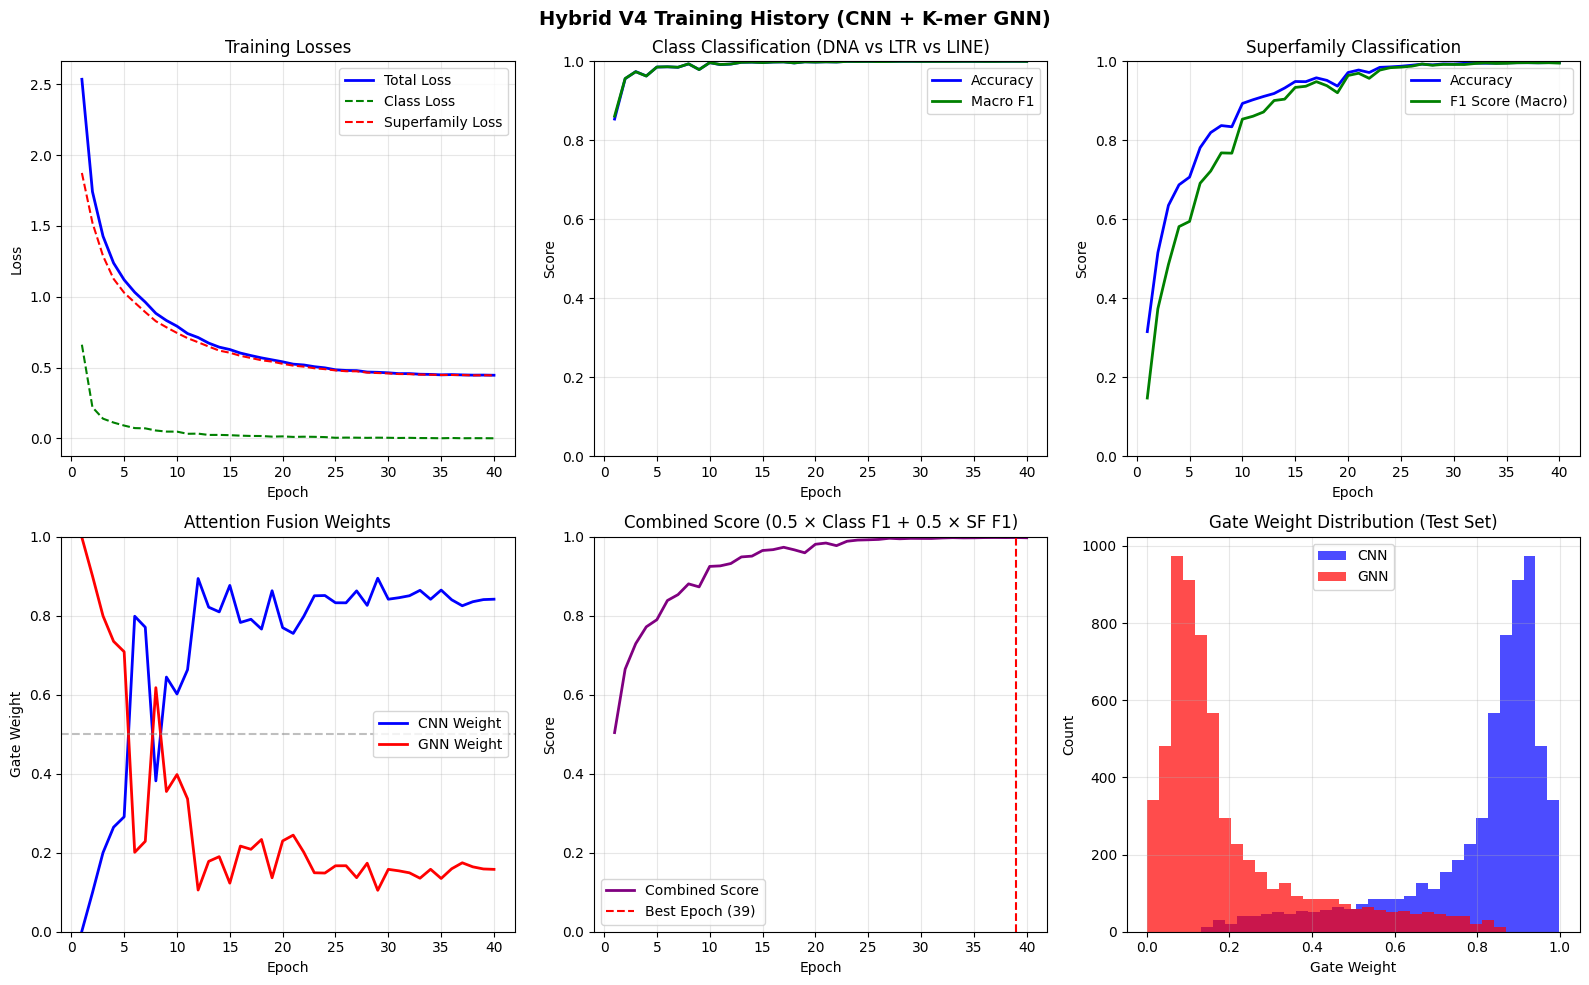

In [18]:
# ============ Plot Training Curves ============

history = results["history"]
epochs = range(1, len(history["train_loss"]) + 1)

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle("Hybrid V4 Training History (CNN + K-mer GNN)", fontsize=14, fontweight="bold")

# Training losses
ax1 = axes[0, 0]
ax1.plot(epochs, history["train_loss"], "b-", label="Total Loss", linewidth=2)
ax1.plot(epochs, history["train_class_loss"], "g--", label="Class Loss", linewidth=1.5)
ax1.plot(epochs, history["train_sf_loss"], "r--", label="Superfamily Loss", linewidth=1.5)
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")
ax1.set_title("Training Losses")
ax1.legend()
ax1.grid(True, alpha=0.3)

# Class metrics (DNA vs LTR vs LINE)
ax2 = axes[0, 1]
ax2.plot(epochs, history["val_class_acc"], "b-", label="Accuracy", linewidth=2)
ax2.plot(epochs, history["val_class_f1"], "g-", label="Macro F1", linewidth=2)
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Score")
ax2.set_title("Class Classification (DNA vs LTR vs LINE)")
ax2.legend()
ax2.grid(True, alpha=0.3)
ax2.set_ylim([0, 1])

# Superfamily metrics
ax3 = axes[0, 2]
ax3.plot(epochs, history["val_sf_acc"], "b-", label="Accuracy", linewidth=2)
ax3.plot(epochs, history["val_sf_f1"], "g-", label="F1 Score (Macro)", linewidth=2)
ax3.set_xlabel("Epoch")
ax3.set_ylabel("Score")
ax3.set_title("Superfamily Classification")
ax3.legend()
ax3.grid(True, alpha=0.3)
ax3.set_ylim([0, 1])

# Gate weights over training
ax4 = axes[1, 0]
ax4.plot(epochs, history["gate_weights_cnn"], "b-", label="CNN Weight", linewidth=2)
ax4.plot(epochs, history["gate_weights_gnn"], "r-", label="GNN Weight", linewidth=2)
ax4.axhline(y=0.5, color="gray", linestyle="--", alpha=0.5)
ax4.set_xlabel("Epoch")
ax4.set_ylabel("Gate Weight")
ax4.set_title("Attention Fusion Weights")
ax4.legend()
ax4.grid(True, alpha=0.3)
ax4.set_ylim([0, 1])

# Combined score
ax5 = axes[1, 1]
combined = [0.5 * b + 0.5 * s for b, s in zip(history["val_class_f1"], history["val_sf_f1"])]
ax5.plot(epochs, combined, "purple", label="Combined Score", linewidth=2)
best_epoch = results["best_epoch"]
ax5.axvline(x=best_epoch, color="red", linestyle="--", label=f"Best Epoch ({best_epoch})")
ax5.set_xlabel("Epoch")
ax5.set_ylabel("Score")
ax5.set_title("Combined Score (0.5 × Class F1 + 0.5 × SF F1)")
ax5.legend()
ax5.grid(True, alpha=0.3)
ax5.set_ylim([0, 1])

# Gate weight distribution (final)
ax6 = axes[1, 2]
ax6.hist(results["gate_weights_cnn"], bins=30, alpha=0.7, label="CNN", color="blue")
ax6.hist(results["gate_weights_gnn"], bins=30, alpha=0.7, label="GNN", color="red")
ax6.set_xlabel("Gate Weight")
ax6.set_ylabel("Count")
ax6.set_title("Gate Weight Distribution (Test Set)")
ax6.legend()
ax6.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("hybrid_v4_training_curves.png", dpi=150, bbox_inches="tight")
plt.show()

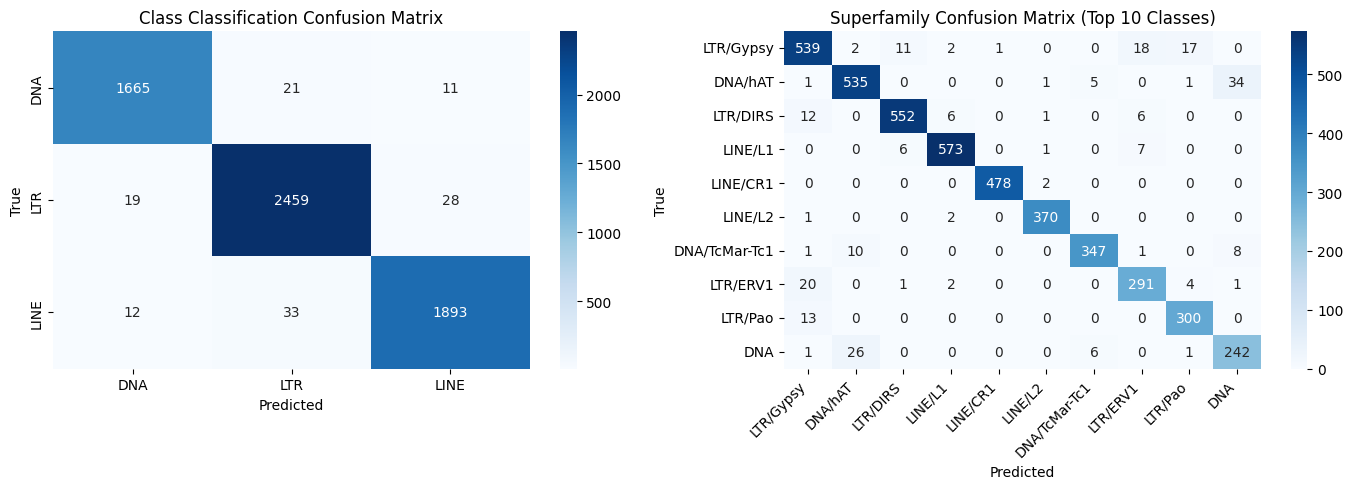

In [19]:
# ============ Confusion Matrices ============

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Class confusion matrix (DNA vs LTR vs LINE)
ax1 = axes[0]
class_names = results["class_names"]
cm_cls = confusion_matrix(results["test_class_true"], results["test_class_pred"])
sns.heatmap(cm_cls, annot=True, fmt="d", cmap="Blues", ax=ax1,
            xticklabels=class_names,
            yticklabels=class_names)
ax1.set_xlabel("Predicted")
ax1.set_ylabel("True")
ax1.set_title("Class Classification Confusion Matrix")

# Superfamily confusion matrix (top classes)
ax2 = axes[1]
sf_names = results["superfamily_names"]
cm_sf = confusion_matrix(results["test_sf_true"], results["test_sf_pred"])

# Show top 10 classes by support
class_support = cm_sf.sum(axis=1)
top_classes = np.argsort(class_support)[::-1][:10]
cm_sf_top = cm_sf[np.ix_(top_classes, top_classes)]
top_names = [sf_names[i] for i in top_classes]

sns.heatmap(cm_sf_top, annot=True, fmt="d", cmap="Blues", ax=ax2,
            xticklabels=top_names, yticklabels=top_names)
ax2.set_xlabel("Predicted")
ax2.set_ylabel("True")
ax2.set_title("Superfamily Confusion Matrix (Top 10 Classes)")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

plt.tight_layout()
plt.savefig("hybrid_v4_confusion_matrices.png", dpi=150, bbox_inches="tight")
plt.show()

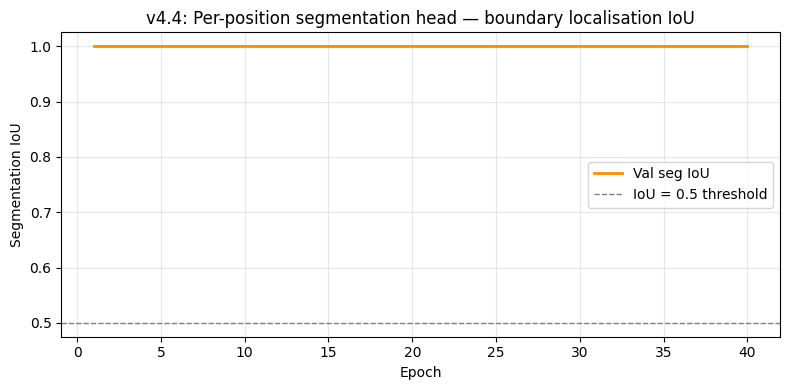

Final val seg IoU: 1.0000
Peak val seg IoU:  1.0000 at epoch 1
Held-out test seg IoU: 1.0000


In [20]:
# ============ [v4.4] Segmentation IoU Training Curve ============
# Shows whether the boundary localisation head improves over training.
# IoU > 0.5 at convergence means the model has learned to localise the
# sequence within the canvas — compare to v4.3 baseline (Pearson r ≈ 0.07–0.18).

history = results["history"]

fig, ax = plt.subplots(figsize=(8, 4))

epochs_axis = range(1, len(history["val_seg_iou"]) + 1)
ax.plot(epochs_axis, history["val_seg_iou"], color="darkorange", linewidth=2, label="Val seg IoU")

ax.axhline(y=0.5, color="grey", linestyle="--", linewidth=1, label="IoU = 0.5 threshold")
ax.set_xlabel("Epoch")
ax.set_ylabel("Segmentation IoU")
ax.set_title("v4.4: Per-position segmentation head — boundary localisation IoU")
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("seg_iou_training_v4.4.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Final val seg IoU: {history['val_seg_iou'][-1]:.4f}")
print(f"Peak val seg IoU:  {max(history['val_seg_iou']):.4f} at epoch {history['val_seg_iou'].index(max(history['val_seg_iou'])) + 1}")
if "test_seg_iou" in results:
    print(f"Held-out test seg IoU: {results['test_seg_iou']:.4f}")


## Summary & Model Comparison

In [21]:
# ============ Final Summary ============

print("=" * 60)
print("HYBRID V4.4 MODEL SUMMARY (Multi-class)")
print("=" * 60)

print(f"\nArchitecture:")
print(f"  CNN Tower: width={CNN_WIDTH}, kernels={MOTIF_KERNELS}")
print(f"  GNN Tower: k={KMER_K}, hidden={GNN_HIDDEN}, layers={GNN_LAYERS}")
print(f"  Fusion: dim={FUSION_DIM}, heads={NUM_HEADS}")

best_idx = results["best_epoch"] - 1
history = results["history"]

print(f"\nBest Epoch: {results['best_epoch']}")
print(f"\nClass Classification (DNA vs LTR vs LINE):")
print(f"  Accuracy: {history['val_class_acc'][best_idx]:.4f}")
print(f"  Macro F1: {history['val_class_f1'][best_idx]:.4f}")

print(f"\nSuperfamily Classification:")
print(f"  Accuracy: {history['val_sf_acc'][best_idx]:.4f}")
print(f"  Macro F1: {history['val_sf_f1'][best_idx]:.4f}")

print(f"\nFusion Gate Weights (avg at best epoch):")
print(f"  CNN: {history['gate_weights_cnn'][best_idx]:.4f}")
print(f"  GNN: {history['gate_weights_gnn'][best_idx]:.4f}")

combined_score = 0.5 * history["val_class_f1"][best_idx] + 0.5 * history["val_sf_f1"][best_idx]
print(f"\nCombined Score: {combined_score:.4f}")

print(f"\nClasses: {results['class_names']}")
print(f"Superfamilies ({len(results['superfamily_names'])}): {results['superfamily_names']}")

HYBRID V4.3 MODEL SUMMARY (Multi-class)

Architecture:
  CNN Tower: width=128, kernels=(7, 15, 21)
  GNN Tower: k=7, hidden=128, layers=3
  Fusion: dim=256, heads=4

Best Epoch: 39

Class Classification (DNA vs LTR vs LINE):
  Accuracy: 1.0000
  Macro F1: 1.0000

Superfamily Classification:
  Accuracy: 0.9967
  Macro F1: 0.9965

Fusion Gate Weights (avg at best epoch):
  CNN: 0.8411
  GNN: 0.1589

Combined Score: 0.9982

Classes: ['DNA', 'LTR', 'LINE']
Superfamilies (23): ['DNA', 'DNA/Academ-1', 'DNA/CMC', 'DNA/Maverick', 'DNA/PIF-Harbinger', 'DNA/PiggyBac', 'DNA/TcMar-Tc1', 'DNA/hAT', 'LINE/CR1', 'LINE/L1', 'LINE/L1-Tx1', 'LINE/L2', 'LINE/RTE', 'LINE/RTE-X', 'LINE/Rex-Babar', 'LTR', 'LTR/Copia', 'LTR/DIRS', 'LTR/ERV1', 'LTR/ERV2', 'LTR/ERV3', 'LTR/Gypsy', 'LTR/Pao']


## Feature Analysis: K-mer vs CNN Contribution

Investigating whether k-mer features alone can separate DNA/LTR/LINE classes.

In [22]:
# ============ K-mer Feature Analysis (No Model Needed) ============
# Test if k-mer features alone can separate DNA/LTR/LINE

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score
import warnings
warnings.filterwarnings('ignore')

# Load a sample of data for analysis
print("Loading data for k-mer analysis...")
headers, sequences = read_fasta(FASTA_PATH)
label_dict, class_dict = load_multiclass_labels(LABEL_PATH, keep_classes=KEEP_CLASSES)

# Match and sample
sample_h, sample_s, sample_class = [], [], []
for h, s in zip(headers, sequences):
    if h in label_dict:
        sample_h.append(h)
        sample_s.append(s)
        sample_class.append(class_dict[h])

# Subsample for speed (5000 samples)
np.random.seed(42)
n_sample = min(5000, len(sample_h))
idx = np.random.choice(len(sample_h), n_sample, replace=False)
sample_h = [sample_h[i] for i in idx]
sample_s = [sample_s[i] for i in idx]
sample_class = np.array([sample_class[i] for i in idx])

print(f"Sampled {n_sample} sequences")
print(f"Class distribution: {dict(zip(KEEP_CLASSES, np.bincount(sample_class)))}")

# Compute k-mer features
print("\nComputing k-mer features...")
featurizer = KmerWindowFeaturizer(k=KMER_K, dim=KMER_DIM, window=KMER_WINDOW, stride=KMER_STRIDE, add_pos=False, l2_normalize=True)

kmer_features = []
for seq in tqdm(sample_s, desc="Featurizing"):
    X, _ = featurizer.featurize_sequence(seq)
    # Average over windows to get single vector per sequence
    kmer_features.append(X.mean(axis=0))

X_kmer = np.array(kmer_features)
y = sample_class

print(f"K-mer feature shape: {X_kmer.shape}")

Loading data for k-mer analysis...
Loaded 50431 sequences (filtered to ['DNA', 'LTR', 'LINE'])
\nSuperfamily distribution by class:
\n  DNA (10779 total):
    ✓ DNA/hAT: 4900 (9.7%)
    ✓ DNA/TcMar-Tc1: 1875 (3.7%)
    ✓ DNA: 1530 (3.0%)
    ✓ DNA/PIF-Harbinger: 790 (1.6%)
    ✓ DNA/PiggyBac: 563 (1.1%)
    ✓ DNA/Academ-1: 415 (0.8%)
    ✓ DNA/CMC: 180 (0.4%)
    ✓ DNA/Maverick: 129 (0.3%)
    ✓ DNA/Sola-2: 93 (0.2%)
    ✓ DNA/Kolobok: 86 (0.2%)
    ✓ DNA/P: 77 (0.2%)
    ✓ DNA/Sola-1: 43 (0.1%)
    ✓ DNA/PIF-ISL2EU: 38 (0.1%)
    ✓ DNA/MULE-MuDR: 23 (0.0%)
    ✓ DNA/Crypton-V: 19 (0.0%)
    ✓ DNA/Merlin: 12 (0.0%)
    ✓ DNA/Ginger-1: 4 (0.0%)
    ✓ DNA/Dada: 2 (0.0%)
\n  LTR (25568 total):
    ✓ LTR/Gypsy: 11913 (23.6%)
    ✓ LTR/DIRS: 7108 (14.1%)
    ✓ LTR/ERV1: 1709 (3.4%)
    ✓ LTR/Pao: 1578 (3.1%)
    ✓ LTR/ERV2: 1116 (2.2%)
    ✓ LTR: 953 (1.9%)
    ✓ LTR/ERV3: 667 (1.3%)
    ✓ LTR/Copia: 522 (1.0%)
    ✓ LTR/ERV: 1 (0.0%)
    ✓ LTR/ERV4: 1 (0.0%)
\n  LINE (14084 total):
    ✓ L

Featurizing:   0%|          | 0/5000 [00:00<?, ?it/s]

K-mer feature shape: (5000, 2048)


In [23]:
# ============ K-mer Classification Test ============
# Can simple classifiers separate classes using only k-mer features?

# Check if cell 32 was run first
if 'X_kmer' not in dir() or 'y' not in dir():
    raise RuntimeError("⚠️ Run Cell 32 (K-mer Feature Analysis) first to compute X_kmer and y!")

print("=" * 60)
print("K-MER FEATURE SEPARABILITY TEST")
print("=" * 60)

# Test 1: Logistic Regression
print("\n1. Logistic Regression (k-mer features only):")
lr = LogisticRegression(max_iter=1000, random_state=42)
lr_scores = cross_val_score(lr, X_kmer, y, cv=5, scoring='accuracy')
lr_f1 = cross_val_score(lr, X_kmer, y, cv=5, scoring='f1_macro')
print(f"   Accuracy: {lr_scores.mean():.4f} ± {lr_scores.std():.4f}")
print(f"   Macro F1: {lr_f1.mean():.4f} ± {lr_f1.std():.4f}")

# Test 2: Random Forest  
print("\n2. Random Forest (k-mer features only):")
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_scores = cross_val_score(rf, X_kmer, y, cv=5, scoring='accuracy')
rf_f1 = cross_val_score(rf, X_kmer, y, cv=5, scoring='f1_macro')
print(f"   Accuracy: {rf_scores.mean():.4f} ± {rf_scores.std():.4f}")
print(f"   Macro F1: {rf_f1.mean():.4f} ± {rf_f1.std():.4f}")

# Baseline comparison
majority_baseline = np.bincount(y).max() / len(y)
print(f"\n3. Baseline (majority class): {majority_baseline:.4f}")

print(f"\n=> K-mer features alone achieve {lr_f1.mean():.1%} macro F1")
print(f"   This is {lr_f1.mean()/majority_baseline:.2f}x better than random!")
if lr_f1.mean() > 0.85:
    print("   ⚠️  K-mer composition strongly separates DNA/LTR/LINE!")
    print("   The class head task is inherently easy due to sequence composition.")

K-MER FEATURE SEPARABILITY TEST

1. Logistic Regression (k-mer features only):
   Accuracy: 0.8636 ± 0.0095
   Macro F1: 0.8554 ± 0.0099

2. Random Forest (k-mer features only):
   Accuracy: 0.8570 ± 0.0128
   Macro F1: 0.8477 ± 0.0150

3. Baseline (majority class): 0.4994

=> K-mer features alone achieve 85.5% macro F1
   This is 1.71x better than random!
   ⚠️  K-mer composition strongly separates DNA/LTR/LINE!
   The class head task is inherently easy due to sequence composition.


Computing PCA...
Computing t-SNE (on 2000 samples)...


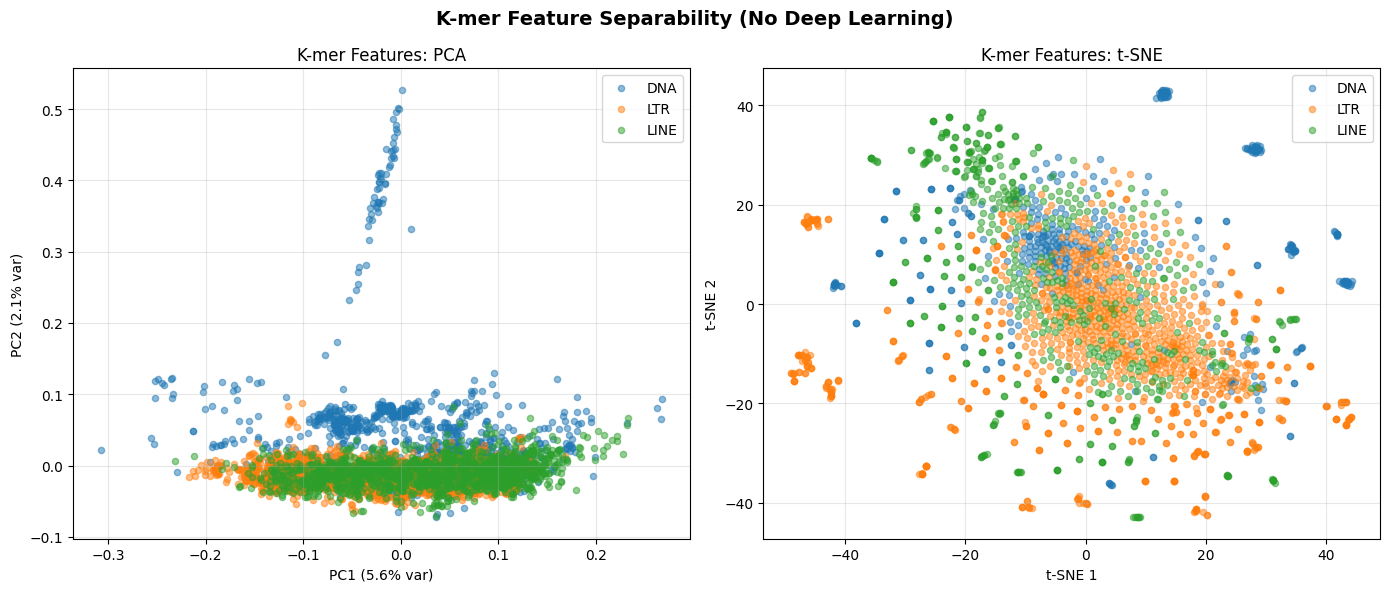


=> If clusters are well-separated, k-mer composition alone distinguishes TE types!


In [24]:
# ============ Visualize K-mer Feature Space ============

# Check if cell 32 was run first
if 'X_kmer' not in dir() or 'y' not in dir():
    raise RuntimeError("⚠️ Run Cell 32 (K-mer Feature Analysis) first to compute X_kmer and y!")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# PCA visualization
print("Computing PCA...")
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_kmer)

ax1 = axes[0]
colors = ['#1f77b4', '#ff7f0e', '#2ca02c']  # DNA=blue, LTR=orange, LINE=green
for i, cls in enumerate(KEEP_CLASSES):
    mask = y == i
    ax1.scatter(X_pca[mask, 0], X_pca[mask, 1], c=colors[i], label=cls, alpha=0.5, s=20)
ax1.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%} var)")
ax1.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%} var)")
ax1.set_title("K-mer Features: PCA")
ax1.legend()
ax1.grid(True, alpha=0.3)

# t-SNE visualization (subsample for speed)
print("Computing t-SNE (on 2000 samples)...")
tsne_idx = np.random.choice(len(X_kmer), min(2000, len(X_kmer)), replace=False)
X_tsne_sub = X_kmer[tsne_idx]
y_tsne_sub = y[tsne_idx]

tsne = TSNE(n_components=2, perplexity=30, random_state=42)
X_tsne = tsne.fit_transform(X_tsne_sub)

ax2 = axes[1]
for i, cls in enumerate(KEEP_CLASSES):
    mask = y_tsne_sub == i
    ax2.scatter(X_tsne[mask, 0], X_tsne[mask, 1], c=colors[i], label=cls, alpha=0.5, s=20)
ax2.set_xlabel("t-SNE 1")
ax2.set_ylabel("t-SNE 2")
ax2.set_title("K-mer Features: t-SNE")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.suptitle("K-mer Feature Separability (No Deep Learning)", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("kmer_class_separation.png", dpi=150, bbox_inches='tight')
plt.show()

print("\n=> If clusters are well-separated, k-mer composition alone distinguishes TE types!")

GATE WEIGHT ANALYSIS (CNN vs GNN Contribution)
Loaded history from training results.

History spans 40 epochs

Epoch 1:  CNN=0.002, GNN=0.998
Best (epoch 39): CNN=0.841, GNN=0.159
Final:    CNN=0.842, GNN=0.158

⚠️  Model relies MORE on CNN (motif) features than GNN!


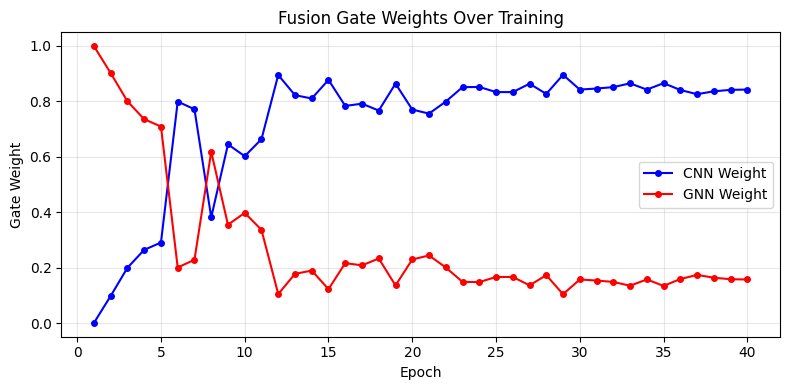

In [25]:
# ============ Gate Weight Analysis (Load from Checkpoint) ============
# Analyze how the model weighs CNN vs GNN features

import glob

print("=" * 60)
print("GATE WEIGHT ANALYSIS (CNN vs GNN Contribution)")
print("=" * 60)

# Try to load history from checkpoint if 'results' not available
if 'results' in dir() and results is not None:
    history = results["history"]
    best_epoch = results.get("best_epoch", len(history.get("val_class_f1", [])))
    print("Loaded history from training results.\n")
else:
    # Load from checkpoint file
    ckpt_files = sorted(glob.glob("hybrid_v4.4_epoch*.pt"))
    if not ckpt_files:
        print("No checkpoint files found (hybrid_v4.4_epoch*.pt)")
        print("Run training first or ensure checkpoint files are in this directory.")
        history = None
    else:
        latest_ckpt = ckpt_files[-1]
        print(f"Loading from checkpoint: {latest_ckpt}")
        ckpt = torch.load(latest_ckpt, map_location="cpu", weights_only=False)
        history = ckpt.get("history", {})
        best_epoch = ckpt.get("epoch", len(history.get("val_class_f1", [])))
        print(f"Checkpoint epoch: {ckpt.get('epoch', 'unknown')}\n")

if history is not None:
    gate_cnn = history.get("gate_weights_cnn", [])
    gate_gnn = history.get("gate_weights_gnn", [])
    
    if gate_cnn and gate_gnn:
        n_epochs = len(gate_cnn)
        print(f"History spans {n_epochs} epochs")
        print(f"\nEpoch 1:  CNN={gate_cnn[0]:.3f}, GNN={gate_gnn[0]:.3f}")
        
        if n_epochs > 1:
            # Find best epoch based on combined F1
            val_class_f1 = history.get("val_class_f1", [])
            val_sf_f1 = history.get("val_sf_f1", [])
            if val_class_f1 and val_sf_f1:
                combined = [0.5*c + 0.5*s for c, s in zip(val_class_f1, val_sf_f1)]
                best_idx = np.argmax(combined)
                print(f"Best (epoch {best_idx+1}): CNN={gate_cnn[best_idx]:.3f}, GNN={gate_gnn[best_idx]:.3f}")
        
        print(f"Final:    CNN={gate_cnn[-1]:.3f}, GNN={gate_gnn[-1]:.3f}")
        
        avg_gnn = np.mean(gate_gnn)
        avg_cnn = np.mean(gate_cnn)
        if avg_gnn > 0.55:
            print("\n⚠️  Model relies MORE on GNN (k-mer) features than CNN!")
            print("   This suggests k-mer composition is highly informative.")
        elif avg_cnn > 0.55:
            print("\n⚠️  Model relies MORE on CNN (motif) features than GNN!")
        else:
            print("\n✓ Model uses both CNN and GNN features roughly equally.")
        
        # Plot gate weight evolution
        if n_epochs > 1:
            epochs = range(1, n_epochs + 1)
            plt.figure(figsize=(8, 4))
            plt.plot(epochs, gate_cnn, 'b-o', label='CNN Weight', markersize=4)
            plt.plot(epochs, gate_gnn, 'r-o', label='GNN Weight', markersize=4)
            plt.xlabel('Epoch')
            plt.ylabel('Gate Weight')
            plt.title('Fusion Gate Weights Over Training')
            plt.legend()
            plt.grid(True, alpha=0.3)
            plt.tight_layout()
            plt.savefig("gate_weights_evolution.png", dpi=150)
            plt.show()
    else:
        print("No gate weight data found in history.")

In [26]:
# ============ Superfamily Analysis within Classes ============
# The real challenge: can k-mers separate superfamilies WITHIN a class?

print("=" * 60)
print("SUPERFAMILY SEPARATION TEST (within classes)")
print("=" * 60)

# Build superfamily labels for samples
sf_labels = []
for h in sample_h:
    tag = label_dict[h]
    sf_labels.append(tag)
sf_labels = np.array(sf_labels)

# Test for each class separately
for cls_id, cls_name in enumerate(KEEP_CLASSES):
    cls_mask = sample_class == cls_id
    X_cls = X_kmer[cls_mask]
    sf_cls = sf_labels[cls_mask]
    
    # Get unique superfamilies in this class
    unique_sf = np.unique(sf_cls)
    n_sf = len(unique_sf)
    
    if n_sf < 2:
        print(f"\n{cls_name}: Only 1 superfamily, skipping")
        continue
    
    # Encode superfamilies
    sf_to_id = {sf: i for i, sf in enumerate(unique_sf)}
    y_sf = np.array([sf_to_id[s] for s in sf_cls])
    
    # Test with logistic regression
    if len(X_cls) > 50:
        lr_sf = LogisticRegression(max_iter=1000, random_state=42)
        try:
            sf_scores = cross_val_score(lr_sf, X_cls, y_sf, cv=min(5, n_sf), scoring='f1_macro')
            print(f"\n{cls_name} ({n_sf} superfamilies, {len(X_cls)} samples):")
            print(f"   K-mer Macro F1: {sf_scores.mean():.4f} ± {sf_scores.std():.4f}")
            
            # Random baseline for this class
            sf_counts = np.bincount(y_sf)
            random_baseline = sf_counts.max() / len(y_sf)
            print(f"   Random baseline: {random_baseline:.4f}")
            print(f"   Improvement: {sf_scores.mean()/random_baseline:.2f}x")
        except Exception as e:
            print(f"\n{cls_name}: Error - {e}")

print("\n=> Superfamily separation is HARDER than class separation!")
print("   This is where the deep learning model adds real value.")

SUPERFAMILY SEPARATION TEST (within classes)

DNA (17 superfamilies, 1069 samples):
   K-mer Macro F1: 0.1392 ± 0.0142
   Random baseline: 0.4715
   Improvement: 0.30x

LTR (8 superfamilies, 2497 samples):
   K-mer Macro F1: 0.1689 ± 0.0058
   Random baseline: 0.4606
   Improvement: 0.37x

LINE (13 superfamilies, 1434 samples):
   K-mer Macro F1: 0.2568 ± 0.0241
   Random baseline: 0.5070
   Improvement: 0.51x

=> Superfamily separation is HARDER than class separation!
   This is where the deep learning model adds real value.


## Overfitting Analysis: Epoch 47 Checkpoint

Evaluate the model on train, validation, and test sets separately to check for overfitting.

In [ ]:
# ============ Overfitting Analysis: Best Checkpoint ============
# Compare performance across train/val/test splits to detect overfitting

import gc
import glob as glob_module
from functools import partial
from sklearn.model_selection import train_test_split

RANDOM_STATE = 42
TEST_SIZE = 0.2              # must match training config
N_FOLDS = 5                  # must match training config


print("=" * 70)
print("OVERFITTING ANALYSIS")
print("=" * 70)

# ---- 1. Load results & config ----
if 'results' not in dir() or results is None:
    results = torch.load("results_v4.4.pt", map_location="cpu", weights_only=False)

class_names       = results['class_names']
superfamily_names  = results['superfamily_names']
superfamily_to_id  = results['superfamily_to_id']
num_classes        = len(class_names)
num_superfamilies  = len(superfamily_names)
print(f"Classes: {num_classes}, Superfamilies: {num_superfamilies}")

# Auto-detect best checkpoint
if 'best_epoch' in results:
    _best_ep = results['best_epoch']
else:
    _ckpt_files = sorted(glob_module.glob("hybrid_v4.4_epoch*.pt"))
    _best_ep = int(_ckpt_files[-1].split('epoch')[1].split('.')[0]) if _ckpt_files else 40
CHECKPOINT_PATH = f"./hybrid_v4.4_epoch{_best_ep}.pt"
print(f"Using checkpoint: {CHECKPOINT_PATH}")

# ---- 2. Rebuild model & load checkpoint ----
_featurizer_ov = KmerWindowFeaturizer(k=KMER_K, dim=KMER_DIM, window=KMER_WINDOW, stride=KMER_STRIDE)

model_ov = HybridTEClassifierV4(
    num_classes=num_classes,
    num_superfamilies=num_superfamilies,
    cnn_width=CNN_WIDTH,
    motif_kernels=MOTIF_KERNELS,
    context_dilations=CONTEXT_DILATIONS,
    pos_freq=POS_FREQ,
    gnn_in_dim=KMER_DIM + 1,
    gnn_hidden=GNN_HIDDEN,
    gnn_layers=GNN_LAYERS,
    fusion_dim=FUSION_DIM,
    num_heads=NUM_HEADS,
    dropout=DROPOUT,
).to(DEVICE)

ckpt = torch.load(CHECKPOINT_PATH, map_location=DEVICE, weights_only=False)
model_ov.load_state_dict(ckpt['model_state_dict'])
model_ov.eval()
print(f"Loaded checkpoint epoch {ckpt.get('epoch', '?')}")

# ---- 3. Reload FULL dataset (with genome exclusion) ----
FASTA_OV   = "../../../data/vgp/all_vgp_tes.fa"
FEAT_OV    = "../../../data/vgp/20260120_features_sf"

def _extract_genome_id(header):
    name_part = header.split('#')[0]
    parts = name_part.rsplit('-', 1)
    return parts[-1] if len(parts) == 2 else None

print("Loading sequences (excluding benchmark genomes)...")
headers_ov, sequences_ov = read_fasta(FASTA_OV)
label_dict_ov, class_dict_ov = load_multiclass_labels(FEAT_OV, keep_classes=tuple(class_names))

# Filter: match labels, exclude benchmark genomes, require known superfamily
all_h, all_s, all_cls, all_sf = [], [], [], []
for h, s in zip(headers_ov, sequences_ov):
    if h not in label_dict_ov:
        continue
    gid = _extract_genome_id(h)
    if gid in EXCLUDE_GENOMES:
        continue
    tag = label_dict_ov[h]
    if tag not in superfamily_to_id:
        continue
    all_h.append(h)
    all_s.append(s)
    all_cls.append(class_dict_ov[h])
    all_sf.append(superfamily_to_id[tag])

del headers_ov, sequences_ov
gc.collect()
print(f"  Loaded {len(all_h)} valid sequences")

# ---- 4. Subsample large superfamilies (same as training) ----
all_sf_arr = np.array(all_sf, dtype=np.int64)
np.random.seed(RANDOM_STATE)
keep_idx = []
for sf_name in superfamily_names:
    sf_id = superfamily_to_id[sf_name]
    indices = np.where(all_sf_arr == sf_id)[0]
    if len(indices) > MAX_PER_SF:
        sampled = np.random.choice(indices, MAX_PER_SF, replace=False)
        keep_idx.extend(sampled)
    else:
        keep_idx.extend(indices)
keep_idx = sorted(keep_idx)
all_h   = [all_h[i]   for i in keep_idx]
all_s   = [all_s[i]   for i in keep_idx]
all_cls = [all_cls[i]  for i in keep_idx]
all_sf  = [all_sf[i]   for i in keep_idx]
print(f"  After subsampling: {len(all_h)} sequences")

# ---- 5. Stratified split (same seed as training) ----
all_tags = [superfamily_names[s] for s in all_sf]
idx_trainval, idx_test = train_test_split(
    np.arange(len(all_h)), test_size=TEST_SIZE,
    stratify=all_tags, random_state=RANDOM_STATE
)
# Approximate train/val split within trainval (first fold of StratifiedKFold)
from sklearn.model_selection import StratifiedKFold
skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE)
fold_splits = list(skf.split(idx_trainval, [all_tags[i] for i in idx_trainval]))
idx_train_in_tv, idx_val_in_tv = fold_splits[0]
idx_train = idx_trainval[idx_train_in_tv]
idx_val   = idx_trainval[idx_val_in_tv]

print(f"  Train: {len(idx_train)}  Val: {len(idx_val)}  Test: {len(idx_test)}")

# ---- 6. Pre-compute k-mer features ----
print("Pre-computing k-mer features...")
all_kmer = []
for s in tqdm(all_s, desc="Featurizing", leave=False):
    X, _ = _featurizer_ov.featurize_sequence(s)
    all_kmer.append(X)

# ---- 7. Evaluate each split ----

split_results = {}
for split_name, indices in [('train', idx_train), ('val', idx_val), ('test', idx_test)]:
    sub_h     = [all_h[i]    for i in indices]
    sub_s     = [all_s[i]    for i in indices]
    sub_cls   = np.array([all_cls[i] for i in indices], dtype=np.int64)
    sub_sf    = np.array([all_sf[i]  for i in indices], dtype=np.int64)
    sub_kmer  = [all_kmer[i] for i in indices]
    
    ds = HybridDataset(
        headers=sub_h, sequences=sub_s,
        binary_labels=sub_sf, class_labels=sub_cls,
        kmer_features=sub_kmer, fixed_length=FIXED_LENGTH,
    )
    loader = torch.utils.data.DataLoader(
        ds, batch_size=64, shuffle=False,
        collate_fn=partial(collate_hybrid, fixed_length=FIXED_LENGTH),
        num_workers=0,
    )
    
    all_sf_true, all_sf_pred = [], []
    with torch.no_grad():
        for batch in loader:
            _, X_cnn, mask_b, Y_sf_b, Y_cls_b, x_gnn, edge_index, batch_vec = batch
            X_cnn = X_cnn.to(DEVICE)
            mask_b = mask_b.to(DEVICE)
            x_gnn = x_gnn.to(DEVICE)
            edge_index = edge_index.to(DEVICE)
            batch_vec = batch_vec.to(DEVICE)
            cls_logits, sf_logits, _, _ = model_ov(X_cnn, mask_b, x_gnn, edge_index, batch_vec)
            all_sf_true.extend(Y_sf_b.tolist())
            all_sf_pred.extend(sf_logits.argmax(dim=1).cpu().tolist())
    
    # Superfamily metrics
    sf_f1_macro = f1_score(all_sf_true, all_sf_pred, average='macro', zero_division=0)
    sf_f1_weighted = f1_score(all_sf_true, all_sf_pred, average='weighted', zero_division=0)
    sf_acc = sum(t == p for t, p in zip(all_sf_true, all_sf_pred)) / len(all_sf_true)
    
    # Class-level (derive from superfamily)
    cls_true = [superfamily_names[t].split('/')[0] for t in all_sf_true]
    cls_pred = [superfamily_names[p].split('/')[0] for p in all_sf_pred]
    cls_f1 = f1_score(cls_true, cls_pred, average='macro', zero_division=0)
    cls_acc = sum(t == p for t, p in zip(cls_true, cls_pred)) / len(cls_true)
    
    split_results[split_name] = {
        'sf_f1_macro': sf_f1_macro, 'sf_f1_weighted': sf_f1_weighted, 'sf_acc': sf_acc,
        'cls_f1': cls_f1, 'cls_acc': cls_acc, 'n': len(indices)
    }
    print(f"  {split_name:5s}  (n={len(indices):6d})  SF-F1m={sf_f1_macro:.4f}  SF-F1w={sf_f1_weighted:.4f}  SF-Acc={sf_acc:.4f}  Cls-F1={cls_f1:.4f}  Cls-Acc={cls_acc:.4f}")

# ---- 8. Summary ----
print("\n" + "=" * 70)
print("OVERFITTING SUMMARY")
print("=" * 70)
print(f"{'Split':>7s}  {'N':>6s}  {'SF-F1(m)':>8s}  {'SF-F1(w)':>8s}  {'SF-Acc':>7s}  {'Cls-F1':>7s}  {'Cls-Acc':>7s}")
print("-" * 70)
for s in ['train', 'val', 'test']:
    r = split_results[s]
    print(f"{s:>7s}  {r['n']:>6d}  {r['sf_f1_macro']:>8.4f}  {r['sf_f1_weighted']:>8.4f}  {r['sf_acc']:>7.4f}  {r['cls_f1']:>7.4f}  {r['cls_acc']:>7.4f}")
gap_sf = split_results['train']['sf_f1_macro'] - split_results['test']['sf_f1_macro']
gap_cls = split_results['train']['cls_f1'] - split_results['test']['cls_f1']
print(f"\nTrain-Test gap:  SF-F1 = {gap_sf:+.4f},  Cls-F1 = {gap_cls:+.4f}")
if gap_sf > 0.10:
    print("⚠️  Possible overfitting (SF-F1 gap > 0.10)")
elif gap_sf > 0.05:
    print("⚡ Mild overfitting (SF-F1 gap 0.05-0.10)")
else:
    print("✅ No significant overfitting detected")

del model_ov, ckpt, all_h, all_s, all_cls, all_sf, all_kmer

gc.collect()

OVERFITTING ANALYSIS
Classes: 3, Superfamilies: 23
Using checkpoint: ./hybrid_v4.4_epoch39.pt
Loaded checkpoint epoch 39
Loading sequences (excluding benchmark genomes)...
Loaded 50431 sequences (filtered to ('DNA', 'LTR', 'LINE'))
\nSuperfamily distribution by class:
\n  DNA (10779 total):
    ✓ DNA/hAT: 4900 (9.7%)
    ✓ DNA/TcMar-Tc1: 1875 (3.7%)
    ✓ DNA: 1530 (3.0%)
    ✓ DNA/PIF-Harbinger: 790 (1.6%)
    ✓ DNA/PiggyBac: 563 (1.1%)
    ✓ DNA/Academ-1: 415 (0.8%)
    ✓ DNA/CMC: 180 (0.4%)
    ✓ DNA/Maverick: 129 (0.3%)
    ✓ DNA/Sola-2: 93 (0.2%)
    ✓ DNA/Kolobok: 86 (0.2%)
    ✓ DNA/P: 77 (0.2%)
    ✓ DNA/Sola-1: 43 (0.1%)
    ✓ DNA/PIF-ISL2EU: 38 (0.1%)
    ✓ DNA/MULE-MuDR: 23 (0.0%)
    ✓ DNA/Crypton-V: 19 (0.0%)
    ✓ DNA/Merlin: 12 (0.0%)
    ✓ DNA/Ginger-1: 4 (0.0%)
    ✓ DNA/Dada: 2 (0.0%)
\n  LTR (25568 total):
    ✓ LTR/Gypsy: 11913 (23.6%)
    ✓ LTR/DIRS: 7108 (14.1%)
    ✓ LTR/ERV1: 1709 (3.4%)
    ✓ LTR/Pao: 1578 (3.1%)
    ✓ LTR/ERV2: 1116 (2.2%)
    ✓ LTR: 953 (1.9%

Featurizing:   0%|          | 0/30701 [00:00<?, ?it/s]

  train  (n= 19648)  SF-F1m=0.9962  SF-F1w=0.9966  SF-Acc=0.9966  Cls-F1=0.9998  Cls-Acc=0.9998
  val    (n=  4912)  SF-F1m=0.9968  SF-F1w=0.9969  SF-Acc=0.9969  Cls-F1=0.9998  Cls-Acc=0.9998


## Benchmark Evaluation on Curated Libraries

Evaluate the best model checkpoint on the three held-out curated libraries from mini_benchmark:
- **bTaeGut** (zebra finch) — 543 sequences
- **mOrnAna** (platypus) — 380 sequences
- **rAllMis** (alligator) — 1196 sequences

Labels follow RepeatMasker format: `>Name#CLASS/SUPERFAMILY @Taxon [S:score]`.
Only sequences with top-level class in {DNA, LTR, LINE} are evaluated. For superfamily evaluation, labels are matched to the model's known superfamilies (exact match or parent-level fallback).

In [34]:
# ============ Benchmark Evaluation: Curated Libraries ============
import gc
import glob as glob_module
from functools import partial
from collections import Counter, defaultdict
from sklearn.metrics import f1_score, classification_report, confusion_matrix

print("=" * 70)
print("BENCHMARK EVALUATION ON CURATED LIBRARIES")
print("=" * 70)

# ---- Configuration ----
BENCHMARK_DIR = "../../../data/mini_benchmark"
BENCHMARK_FILES = {
    'bTaeGut': f"{BENCHMARK_DIR}/bTaeGut/taeniopygia_guttata_lib.fa",
    'mOrnAna': f"{BENCHMARK_DIR}/mOrnAna/platypus_curated_lib.fa",
    'rAllMis': f"{BENCHMARK_DIR}/rAllMis/Aligator_mississippiensis_lib.fa",
}
MAX_SEQ_LEN = FIXED_LENGTH  # from config cell
BATCH_SIZE_BENCH = 32
DEVICE_BENCH = DEVICE  # from config cell

# ---- 1. Load results + rebuild model if needed ----
if 'results' not in dir() or results is None:
    results = torch.load("results_v4.4.pt", map_location="cpu", weights_only=False)

class_names       = results['class_names']
superfamily_names  = results['superfamily_names']
superfamily_to_id  = results['superfamily_to_id']
id_to_superfamily  = {v: k for k, v in superfamily_to_id.items()}
class_to_id        = {c: i for i, c in enumerate(class_names)}
num_classes        = len(class_names)
num_superfamilies  = len(superfamily_names)

print(f"Model classes: {class_names}")
print(f"Model superfamilies ({num_superfamilies}): {superfamily_names}")

# Auto-detect best checkpoint
if 'results' in dir() and results is not None and 'best_epoch' in results:
    _best_ep = results['best_epoch']
else:
    _ckpt_files = sorted(glob_module.glob("hybrid_v4.4_epoch*.pt"))
    _best_ep = int(_ckpt_files[-1].split('epoch')[1].split('.')[0]) if _ckpt_files else 40
CHECKPOINT_PATH_BENCH = f"./hybrid_v4.4_epoch{_best_ep}.pt"

# Rebuild model (v4.4: includes pos_freq for sinusoidal positional encoding)
_featurizer = KmerWindowFeaturizer(k=KMER_K, dim=KMER_DIM, window=KMER_WINDOW, stride=KMER_STRIDE)
model_bench = HybridTEClassifierV4(
    num_classes=num_classes,
    num_superfamilies=num_superfamilies,
    cnn_width=CNN_WIDTH,
    motif_kernels=MOTIF_KERNELS,
    context_dilations=CONTEXT_DILATIONS,
    rc_mode=RC_FUSION_MODE,
    pos_freq=POS_FREQ,
    gnn_in_dim=KMER_DIM + 1,
    gnn_hidden=GNN_HIDDEN,
    gnn_layers=GNN_LAYERS,
    fusion_dim=FUSION_DIM,
    num_heads=NUM_HEADS,
    dropout=DROPOUT,
).to(DEVICE_BENCH)

ckpt = torch.load(CHECKPOINT_PATH_BENCH, map_location=DEVICE_BENCH, weights_only=False)
model_bench.load_state_dict(ckpt['model_state_dict'])
model_bench.eval()
print(f"Loaded checkpoint: epoch {ckpt.get('epoch', '?')}")

# ---- 2. Parse benchmark FASTA with label mapping ----
def parse_benchmark_fasta(path, superfamily_to_id, class_names):
    """
    Parse a curated library FASTA file.
    Header format: >Name#CLASS/SUPERFAMILY @Taxon [S:score]

    Returns lists of (header, sequence, class_label, sf_label, sf_id) for matched entries,
    plus statistics on skipped/unmatched labels.
    """
    keep_classes = set(class_names)

    # Build parent-mapping: e.g. "DNA/hAT-Charlie" -> "DNA/hAT" -> "DNA"
    def find_sf_id(tag):
        """Try exact match, then parent-level fallback."""
        if tag in superfamily_to_id:
            return superfamily_to_id[tag], tag, 'exact'
        # Try parent: "DNA/hAT-Charlie" -> "DNA/hAT"
        if '/' in tag:
            parts = tag.split('/')
            base_class = parts[0]
            sf_part = parts[1]
            if '-' in sf_part:
                parent = f"{base_class}/{sf_part.split('-')[0]}"
                if parent in superfamily_to_id:
                    return superfamily_to_id[parent], parent, 'parent'
            # Try class-only: "DNA/hAT-Charlie" -> "DNA"
            if base_class in superfamily_to_id:
                return superfamily_to_id[base_class], base_class, 'class_only'
        return None, None, 'unmapped'

    headers, sequences = [], []
    h, buf = None, []
    with open(path) as f:
        for line in f:
            line = line.strip()
            if line.startswith('>'):
                if h:
                    headers.append(h)
                    sequences.append(''.join(buf).upper())
                h, buf = line[1:], []
            else:
                buf.append(line)
        if h:
            headers.append(h)
            sequences.append(''.join(buf).upper())

    # Parse labels
    matched = []
    stats = {'total': len(headers), 'wrong_class': 0, 'no_hash': 0,
             'exact': 0, 'parent': 0, 'class_only': 0, 'unmapped': 0}
    unmapped_labels = Counter()
    mapping_details = defaultdict(list)

    for hdr, seq in zip(headers, sequences):
        # Extract tag from header: "Name#CLASS/SF @Taxon [S:score]"
        if '#' not in hdr:
            stats['no_hash'] += 1
            continue

        tag_part = hdr.split('#', 1)[1]
        tag = tag_part.split()[0].rstrip('?')  # Remove trailing ? and @Taxon

        top_class = tag.split('/')[0]
        if top_class not in keep_classes:
            stats['wrong_class'] += 1
            unmapped_labels[tag_part.split()[0]] += 1
            continue

        sf_id, mapped_to, match_type = find_sf_id(tag)
        if sf_id is None:
            stats['unmapped'] += 1
            unmapped_labels[tag] += 1
            continue

        stats[match_type] += 1
        cls_id = class_to_id[top_class]
        mapping_details[f"{tag} -> {mapped_to} ({match_type})"].append(hdr.split()[0])

        matched.append({
            'header': hdr,
            'sequence': seq,
            'cls_id': cls_id,
            'sf_id': sf_id,
            'original_tag': tag,
            'mapped_to': mapped_to,
            'match_type': match_type,
        })

    return matched, stats, unmapped_labels, mapping_details

# ---- 3. Inference function ----
def run_benchmark_inference(matched_entries, model, featurizer, device, batch_size=32):
    """Run inference on benchmark entries and return predictions."""
    seqs = [e['sequence'] for e in matched_entries]
    sf_ids = [e['sf_id'] for e in matched_entries]
    cls_ids = [e['cls_id'] for e in matched_entries]

    # Pre-compute k-mer features
    kmer_feats = []
    for seq in seqs:
        X, _ = featurizer.featurize_sequence(seq)
        kmer_feats.append(X)

    # Create dataset and dataloader
    headers_list = [e['header'] for e in matched_entries]
    ds = HybridDataset(
        headers=headers_list,
        sequences=seqs,
        binary_labels=sf_ids,  # superfamily as "binary" slot
        class_labels=cls_ids,
        kmer_features=kmer_feats,
        fixed_length=MAX_SEQ_LEN,
    )
    loader = torch.utils.data.DataLoader(
        ds, batch_size=batch_size, shuffle=False,
        collate_fn=partial(collate_hybrid, fixed_length=MAX_SEQ_LEN),
        num_workers=0,
    )

    all_cls_true, all_cls_pred = [], []
    all_sf_true, all_sf_pred = [], []
    all_gate_weights = []

    with torch.no_grad():
        for batch in loader:
            _, X_cnn, mask, Y_sf, Y_cls, x_gnn, edge_index, batch_vec = batch
            X_cnn = X_cnn.to(device)
            mask = mask.to(device)
            x_gnn = x_gnn.to(device)
            edge_index = edge_index.to(device)
            batch_vec = batch_vec.to(device)

            # v4.4: model returns 4 values (class_logits, sf_logits, gate_weights, seg_logits)
            cls_logits, sf_logits, gate_w, _ = model(X_cnn, mask, x_gnn, edge_index, batch_vec)

            all_cls_true.extend(Y_cls.tolist())
            all_cls_pred.extend(cls_logits.argmax(1).cpu().tolist())
            all_sf_true.extend(Y_sf.tolist())
            all_sf_pred.extend(sf_logits.argmax(1).cpu().tolist())
            all_gate_weights.extend(gate_w.cpu().tolist())

    return all_cls_true, all_cls_pred, all_sf_true, all_sf_pred, all_gate_weights

# ---- 4. Run evaluation per genome ----
all_genome_results = {}

for genome_name, fasta_path in sorted(BENCHMARK_FILES.items()):
    print(f"\n{'='*60}")
    print(f"  {genome_name}")
    print(f"{'='*60}")

    matched, stats, unmapped, mappings = parse_benchmark_fasta(
        fasta_path, superfamily_to_id, class_names
    )

    print(f"  Total sequences:     {stats['total']}")
    print(f"  Matched (evaluable): {len(matched)}")
    print(f"    Exact SF match:    {stats['exact']}")
    print(f"    Parent fallback:   {stats['parent']}")
    print(f"    Class-only match:  {stats['class_only']}")
    print(f"  Skipped:")
    print(f"    Wrong class:       {stats['wrong_class']}")
    print(f"    Unmapped SF:       {stats['unmapped']}")
    print(f"    No # in header:    {stats['no_hash']}")

    if unmapped:
        print(f"\n  Unmapped/skipped labels:")
        for lab, cnt in sorted(unmapped.items(), key=lambda x: -x[1])[:15]:
            print(f"    {lab}: {cnt}")

    if not matched:
        print("  ⚠️  No evaluable sequences!")
        continue

    # Run inference
    cls_true, cls_pred, sf_true, sf_pred, gate_w = run_benchmark_inference(
        matched, model_bench, _featurizer, DEVICE_BENCH, BATCH_SIZE_BENCH
    )

    # Class-level metrics
    cls_acc = sum(t == p for t, p in zip(cls_true, cls_pred)) / len(cls_true)
    cls_f1 = f1_score(cls_true, cls_pred, average='macro', zero_division=0)
    cls_f1_w = f1_score(cls_true, cls_pred, average='weighted', zero_division=0)

    # Superfamily-level metrics
    sf_acc = sum(t == p for t, p in zip(sf_true, sf_pred)) / len(sf_true)
    sf_f1 = f1_score(sf_true, sf_pred, average='macro', zero_division=0)
    sf_f1_w = f1_score(sf_true, sf_pred, average='weighted', zero_division=0)

    print(f"\n  Class-level:   Acc={cls_acc:.4f}  F1(macro)={cls_f1:.4f}  F1(weighted)={cls_f1_w:.4f}")
    print(f"  Superfamily:   Acc={sf_acc:.4f}  F1(macro)={sf_f1:.4f}  F1(weighted)={sf_f1_w:.4f}")

    # Per-class breakdown
    print(f"\n  Per-class breakdown:")
    for c_name in class_names:
        c_id = class_to_id[c_name]
        mask_c = [i for i, t in enumerate(cls_true) if t == c_id]
        if not mask_c:
            continue
        c_correct = sum(cls_pred[i] == c_id for i in mask_c)
        c_total = len(mask_c)
        print(f"    {c_name:12s}  {c_correct}/{c_total} correct ({100*c_correct/c_total:.1f}%)")

    # Average gate weights
    avg_gate = np.mean(gate_w, axis=0)
    print(f"\n  Avg gate weights: CNN={avg_gate[0]:.3f}, GNN={avg_gate[1]:.3f}")

    all_genome_results[genome_name] = {
        'matched': len(matched),
        'stats': stats,
        'cls_acc': cls_acc, 'cls_f1': cls_f1, 'cls_f1_w': cls_f1_w,
        'sf_acc': sf_acc, 'sf_f1': sf_f1, 'sf_f1_w': sf_f1_w,
        'cls_true': cls_true, 'cls_pred': cls_pred,
        'sf_true': sf_true, 'sf_pred': sf_pred,
        'gate_weights': gate_w,
    }

# ---- 5. Overall summary ----
print("\n" + "=" * 70)
print("BENCHMARK SUMMARY")
print("=" * 70)

# Aggregate all predictions
all_cls_t = sum((r['cls_true'] for r in all_genome_results.values()), [])
all_cls_p = sum((r['cls_pred'] for r in all_genome_results.values()), [])
all_sf_t = sum((r['sf_true'] for r in all_genome_results.values()), [])
all_sf_p = sum((r['sf_pred'] for r in all_genome_results.values()), [])

print(f"\n{'Genome':>10s}  {'N':>5s}  {'Cls-Acc':>7s}  {'Cls-F1m':>7s}  {'SF-Acc':>7s}  {'SF-F1m':>7s}  {'SF-F1w':>7s}")
print("-" * 70)
for gn in sorted(all_genome_results):
    r = all_genome_results[gn]
    print(f"{gn:>10s}  {r['matched']:>5d}  {r['cls_acc']:>7.4f}  {r['cls_f1']:>7.4f}  {r['sf_acc']:>7.4f}  {r['sf_f1']:>7.4f}  {r['sf_f1_w']:>7.4f}")

total_n = sum(r['matched'] for r in all_genome_results.values())
if total_n > 0:
    overall_cls_acc = sum(t == p for t, p in zip(all_cls_t, all_cls_p)) / len(all_cls_t)
    overall_cls_f1 = f1_score(all_cls_t, all_cls_p, average='macro', zero_division=0)
    overall_sf_acc = sum(t == p for t, p in zip(all_sf_t, all_sf_p)) / len(all_sf_t)
    overall_sf_f1 = f1_score(all_sf_t, all_sf_p, average='macro', zero_division=0)
    overall_sf_f1w = f1_score(all_sf_t, all_sf_p, average='weighted', zero_division=0)
    print("-" * 70)
    print(f"{'OVERALL':>10s}  {total_n:>5d}  {overall_cls_acc:>7.4f}  {overall_cls_f1:>7.4f}  {overall_sf_acc:>7.4f}  {overall_sf_f1:>7.4f}  {overall_sf_f1w:>7.4f}")

# ---- 6. Detailed classification report (overall) ----
print("\n" + "=" * 70)
print("DETAILED CLASSIFICATION REPORT (All genomes, superfamily level)")
print("=" * 70)

# Get unique SF IDs present in true labels
unique_sf_ids = sorted(set(all_sf_t))
sf_target_names = [id_to_superfamily[i] for i in unique_sf_ids]
print(classification_report(all_sf_t, all_sf_p, labels=unique_sf_ids,
                            target_names=sf_target_names, zero_division=0))

del model_bench, ckpt
gc.collect()
print("Done.")


BENCHMARK EVALUATION ON CURATED LIBRARIES
Model classes: ['DNA', 'LTR', 'LINE']
Model superfamilies (23): ['DNA', 'DNA/Academ-1', 'DNA/CMC', 'DNA/Maverick', 'DNA/PIF-Harbinger', 'DNA/PiggyBac', 'DNA/TcMar-Tc1', 'DNA/hAT', 'LINE/CR1', 'LINE/L1', 'LINE/L1-Tx1', 'LINE/L2', 'LINE/RTE', 'LINE/RTE-X', 'LINE/Rex-Babar', 'LTR', 'LTR/Copia', 'LTR/DIRS', 'LTR/ERV1', 'LTR/ERV2', 'LTR/ERV3', 'LTR/Gypsy', 'LTR/Pao']
Loaded checkpoint: epoch 39

  bTaeGut
  Total sequences:     543
  Matched (evaluable): 415
    Exact SF match:    174
    Parent fallback:   10
    Class-only match:  231
  Skipped:
    Wrong class:       127
    Unmapped SF:       1
    No # in header:    0

  Unmapped/skipped labels:
    tRNA: 62
    Unknown: 33
    snRNA: 12
    scRNA: 4
    rRNA: 3
    SINE/MIR: 3
    LINE/R2: 1
    PLE: 1
    RC/Helitron: 1
    RC?/Helitron?: 1
    Satellite: 1
    SINE/5S-Deu-L2: 1
    SINE/Alu: 1
    SINE/tRNA: 1
    SINE/tRNA-CR1: 1

  Class-level:   Acc=0.3542  F1(macro)=0.4674  F1(weighted)=

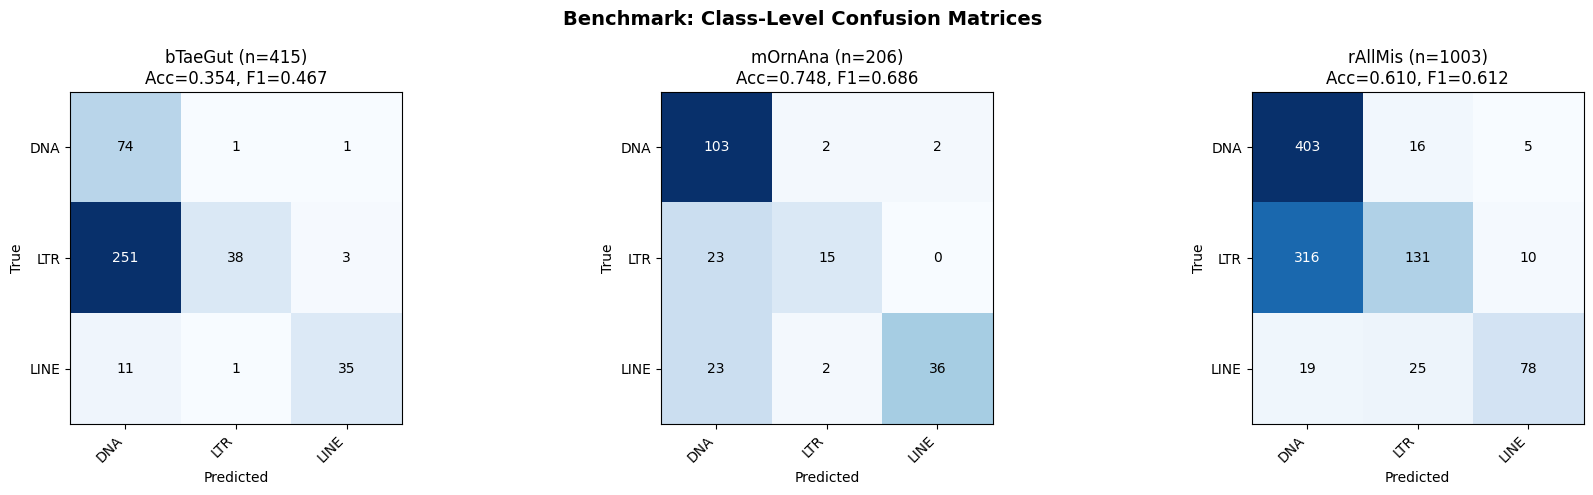

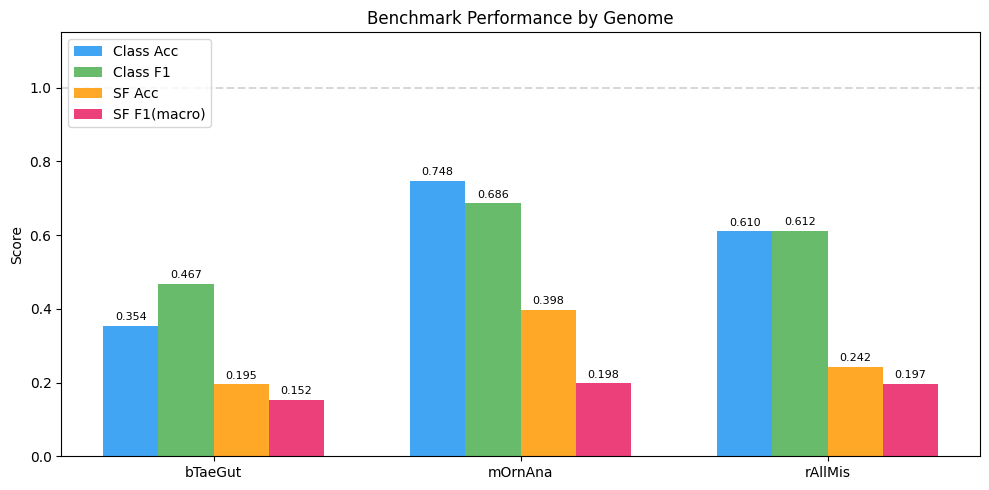

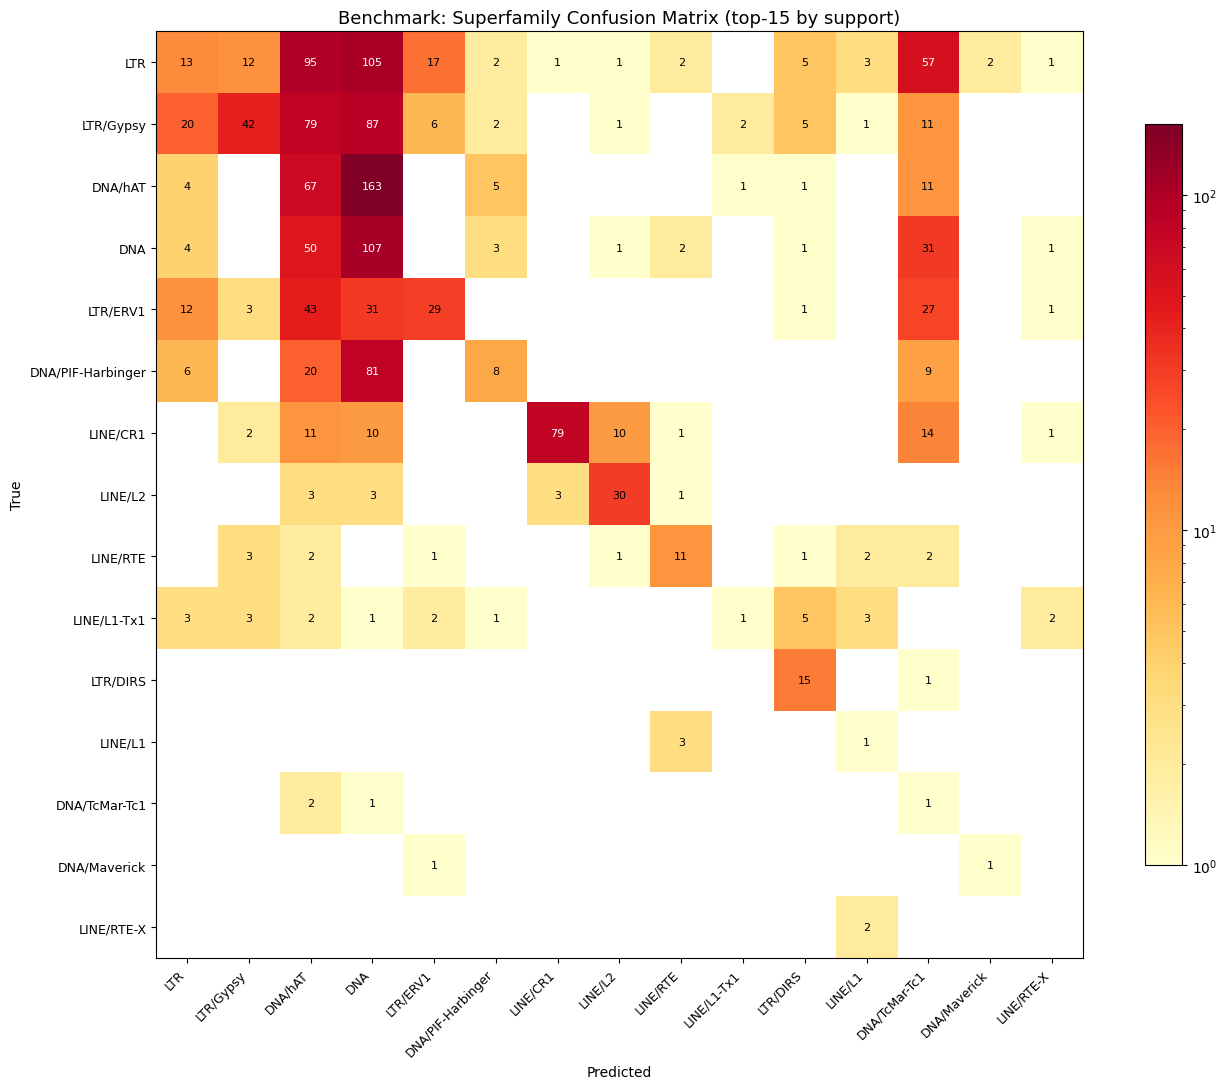

Benchmark visualizations complete.


In [35]:
# ============ Benchmark Visualizations ============
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# ---- 1. Class-level confusion matrices per genome ----
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Benchmark: Class-Level Confusion Matrices", fontsize=14, fontweight='bold')

for ax, gn in zip(axes, sorted(all_genome_results)):
    r = all_genome_results[gn]
    present_cls = sorted(set(r['cls_true'] + r['cls_pred']))
    cm = confusion_matrix(r['cls_true'], r['cls_pred'], labels=present_cls)
    labels = [class_names[i] for i in present_cls]
    
    im = ax.imshow(cm, cmap='Blues', interpolation='nearest')
    ax.set_title(f"{gn} (n={r['matched']})\nAcc={r['cls_acc']:.3f}, F1={r['cls_f1']:.3f}")
    ax.set_xticks(range(len(labels)))
    ax.set_xticklabels(labels, rotation=45, ha='right')
    ax.set_yticks(range(len(labels)))
    ax.set_yticklabels(labels)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    for i in range(len(labels)):
        for j in range(len(labels)):
            val = cm[i, j]
            color = 'white' if val > cm.max() * 0.5 else 'black'
            ax.text(j, i, str(val), ha='center', va='center', color=color, fontsize=10)

plt.tight_layout()
plt.show()

# ---- 2. Per-genome bar chart comparison ----
genomes = sorted(all_genome_results.keys())
metrics = ['cls_acc', 'cls_f1', 'sf_acc', 'sf_f1']
metric_labels = ['Class Acc', 'Class F1', 'SF Acc', 'SF F1(macro)']
colors_bar = ['#2196F3', '#4CAF50', '#FF9800', '#E91E63']

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(genomes))
w = 0.18
for i, (m, ml, c) in enumerate(zip(metrics, metric_labels, colors_bar)):
    vals = [all_genome_results[g][m] for g in genomes]
    ax.bar(x + i * w, vals, w, label=ml, color=c, alpha=0.85)
    for xi, v in zip(x + i * w, vals):
        ax.text(xi, v + 0.01, f"{v:.3f}", ha='center', va='bottom', fontsize=8)

ax.set_xticks(x + 1.5 * w)
ax.set_xticklabels(genomes)
ax.set_ylim(0, 1.15)
ax.set_ylabel("Score")
ax.set_title("Benchmark Performance by Genome")
ax.legend(loc='upper left')
ax.axhline(y=1.0, color='gray', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

# ---- 3. Superfamily confusion matrix (overall, top-N by support) ----
all_sf_t_all = sum((r['sf_true'] for r in all_genome_results.values()), [])
all_sf_p_all = sum((r['sf_pred'] for r in all_genome_results.values()), [])

# Get top SFs by support
sf_counts_bench = Counter(all_sf_t_all)
top_sf_ids = [sf_id for sf_id, _ in sf_counts_bench.most_common(15)]

cm_sf = confusion_matrix(all_sf_t_all, all_sf_p_all, labels=top_sf_ids)
sf_labels = [id_to_superfamily[i] for i in top_sf_ids]

fig, ax = plt.subplots(figsize=(14, 11))
im = ax.imshow(cm_sf, cmap='YlOrRd', interpolation='nearest',
               norm=mcolors.LogNorm(vmin=max(1, cm_sf[cm_sf > 0].min()), vmax=cm_sf.max()))
ax.set_title("Benchmark: Superfamily Confusion Matrix (top-15 by support)", fontsize=13)
ax.set_xticks(range(len(sf_labels)))
ax.set_xticklabels(sf_labels, rotation=45, ha='right', fontsize=9)
ax.set_yticks(range(len(sf_labels)))
ax.set_yticklabels(sf_labels, fontsize=9)
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
for i in range(len(sf_labels)):
    for j in range(len(sf_labels)):
        val = cm_sf[i, j]
        if val > 0:
            color = 'white' if val > cm_sf.max() * 0.3 else 'black'
            ax.text(j, i, str(val), ha='center', va='center', color=color, fontsize=8)
plt.colorbar(im, ax=ax, shrink=0.8)
plt.tight_layout()
plt.show()

print("Benchmark visualizations complete.")